Cell 01 — Notebook Title


# CSE498R Research Project

## Notebook 01 — QUH Data Preflight & Integrity Audit

### Research Topic
**Long-Tail Logit Calibration (LTLC) for Hyperspectral Image Classification**

### Datasets
- QUH-Pingan
- QUH-Qingyun
- QUH-Tangdaowan

### Protocol
Experiment Blueprint v3.1 — Implementation-Locked Protocol

---

## Purpose

This notebook performs the dataset preflight and integrity audit before any preprocessing or model training.

### Main tasks
1. Verify all QUH dataset files.
2. Inspect MATLAB `.mat` file structures.
3. Verify hyperspectral cube and mask dimensions.
4. Validate class labels.
5. Confirm official train/test center pixels are disjoint.
6. Create the fixed stratified 70/30 train-validation split.
7. Calculate class distributions and imbalance ratios.
8. Define Tail, Medium, and Head classes.
9. Calculate training priors and LTLC rarity scores.
10. Save and freeze all split indices for future experiments.

> No PCA, patch extraction, HybridSN training, Logit Adjustment, or LTLC tuning will be performed in Notebook 01.

Cell 02 — Gate 1 Success Criteria

## Gate 1 — Data Integrity Success Criteria

Notebook 01 passes only if:

- All 12 required QUH files are found.
- All `.mat` files load successfully.
- HSI cube dimensions are valid.
- Train/test mask sizes match the corresponding HSI image.
- Labels are valid.
- Official train/test center pixels are disjoint.
- Validation samples are created only from the official training mask.
- Train, validation, and test center indices are mutually disjoint.
- The 70/30 validation split is reproducible.
- Per-class training counts are calculated.
- Imbalance ratios are calculated.
- Tail, Medium, and Head groups are frozen.
- Training priors use only the actual 70% training subset.
- LTLC rarity scores are valid.
- Split indices and metadata are successfully saved.

If any mandatory check fails:

**STOP — do not continue to preprocessing or model training.**

Cell 03 — Mount Google Drive

In [1]:
# ============================================================
# CELL 03 — MOUNT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


Cell 04 — Import Libraries

In [2]:
# ============================================================
# CELL 04 — IMPORT REQUIRED LIBRARIES
# ============================================================

import os
import sys
import json
import random
import hashlib
import platform

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
from scipy.io import loadmat

import sklearn
from sklearn.model_selection import train_test_split

print("All required libraries imported successfully.")

All required libraries imported successfully.


Cell 05 — Environment Information

In [3]:
# ============================================================
# CELL 05 — ENVIRONMENT INFORMATION
# ============================================================

environment_info = {
    "timestamp": datetime.now().isoformat(),
    "python_version": sys.version,
    "platform": platform.platform(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "scipy_version": scipy.__version__,
    "sklearn_version": sklearn.__version__,
}

print("=" * 70)
print("LTLC NOTEBOOK 01 — ENVIRONMENT INFORMATION")
print("=" * 70)

for key, value in environment_info.items():
    print(f"{key:22s}: {value}")

print("=" * 70)

LTLC NOTEBOOK 01 — ENVIRONMENT INFORMATION
timestamp             : 2026-08-12T14:59:58.750656
python_version        : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
platform              : Linux-6.6.122+-x86_64-with-glibc2.35
numpy_version         : 2.0.2
pandas_version        : 2.2.2
scipy_version         : 1.16.3
sklearn_version       : 1.6.1


Cell 06 — Lock Reproducibility

In [4]:
# ============================================================
# CELL 06 — REPRODUCIBILITY CONFIGURATION
# ============================================================

VALIDATION_SPLIT_SEED = 2026
VALIDATION_FRACTION = 0.30
GLOBAL_SEED = 2026

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("=" * 60)
print("REPRODUCIBILITY SETTINGS")
print("=" * 60)

print(f"Global seed              : {GLOBAL_SEED}")
print(f"Validation split seed    : {VALIDATION_SPLIT_SEED}")
print(f"Validation fraction      : {VALIDATION_FRACTION}")
print(f"Training fraction        : {1 - VALIDATION_FRACTION}")
print("Stratified by class      : YES")

print("=" * 60)

REPRODUCIBILITY SETTINGS
Global seed              : 2026
Validation split seed    : 2026
Validation fraction      : 0.3
Training fraction        : 0.7
Stratified by class      : YES


Cell 07 — Project Directory Setup

In [5]:
# ============================================================
# CELL 07 — PROJECT DIRECTORY CONFIGURATION
# ============================================================

PROJECT_ROOT = Path("/content/drive/MyDrive/CSE498/LTLC")

DATA_RAW_DIR = PROJECT_ROOT / "data_raw"
SPLIT_DIR = PROJECT_ROOT / "split_indices"
AUDIT_DIR = PROJECT_ROOT / "audit"
CONFIG_DIR = PROJECT_ROOT / "configs"
DATA_CACHE_DIR = PROJECT_ROOT / "data_cache"
RUNS_DIR = PROJECT_ROOT / "runs"
TABLES_DIR = PROJECT_ROOT / "tables"
FIGURES_DIR = PROJECT_ROOT / "figures"

directories = [
    PROJECT_ROOT,
    DATA_RAW_DIR,
    SPLIT_DIR,
    AUDIT_DIR,
    CONFIG_DIR,
    DATA_CACHE_DIR,
    RUNS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
]

for directory in directories:
    directory.mkdir(parents=True, exist_ok=True)

print("=" * 70)
print("LTLC PROJECT DIRECTORIES")
print("=" * 70)

for directory in directories:
    print(directory)

print("=" * 70)
print("Directory initialization: COMPLETE")

LTLC PROJECT DIRECTORIES
/content/drive/MyDrive/CSE498/LTLC
/content/drive/MyDrive/CSE498/LTLC/data_raw
/content/drive/MyDrive/CSE498/LTLC/split_indices
/content/drive/MyDrive/CSE498/LTLC/audit
/content/drive/MyDrive/CSE498/LTLC/configs
/content/drive/MyDrive/CSE498/LTLC/data_cache
/content/drive/MyDrive/CSE498/LTLC/runs
/content/drive/MyDrive/CSE498/LTLC/tables
/content/drive/MyDrive/CSE498/LTLC/figures
Directory initialization: COMPLETE


Cell 08 — Dataset Registry

In [6]:
# ============================================================
# CELL 08 — QUH DATASET REGISTRY
# ============================================================

DATASETS = {
    "Pingan": {
        "folder": DATA_RAW_DIR / "Pingan",
        "cube_file": "QUH-Pingan.mat",
        "gt_file": "QUH-Pingan_GT.mat",
        "train_file": "Pingan_train.mat",
        "test_file": "Pingan_test.mat",
        "expected_classes": 10,
        "patch_size": 13,
        "pca_components": 15,
    },

    "Qingyun": {
        "folder": DATA_RAW_DIR / "Qingyun",
        "cube_file": "QUH-Qingyun.mat",
        "gt_file": "QUH-Qingyun_GT.mat",
        "train_file": "Qingyun_train.mat",
        "test_file": "Qingyun_test.mat",
        "expected_classes": 6,
        "patch_size": 11,
        "pca_components": 15,
    },

    "Tangdaowan": {
        "folder": DATA_RAW_DIR / "Tangdaowan",
        "cube_file": "QUH-Tangdaowan.mat",
        "gt_file": "QUH-Tangdaowan_GT.mat",
        "train_file": "Tangdaowan_train.mat",
        "test_file": "Tangdaowan_test.mat",
        "expected_classes": 18,
        "patch_size": 9,
        "pca_components": 20,
    },
}

print("Dataset registry created successfully.")

for name, config in DATASETS.items():
    print(
        f"{name:12s} | "
        f"Classes: {config['expected_classes']:2d} | "
        f"Patch: {config['patch_size']}x{config['patch_size']} | "
        f"PCA: {config['pca_components']}"
    )

Dataset registry created successfully.
Pingan       | Classes: 10 | Patch: 13x13 | PCA: 15
Qingyun      | Classes:  6 | Patch: 11x11 | PCA: 15
Tangdaowan   | Classes: 18 | Patch: 9x9 | PCA: 20


Cell 09 — Verify All 12 Files

In [7]:
# ============================================================
# CELL 09 — VERIFY REQUIRED DATASET FILES
# ============================================================

required_file_keys = [
    "cube_file",
    "gt_file",
    "train_file",
    "test_file",
]

all_files_found = True
file_records = []

print("=" * 85)
print("QUH DATASET FILE CHECK")
print("=" * 85)

for dataset_name, config in DATASETS.items():

    print(f"\n[{dataset_name}]")

    for key in required_file_keys:

        file_path = config["folder"] / config[key]
        exists = file_path.exists()

        if exists:
            size_mb = file_path.stat().st_size / (1024 ** 2)
            status = "PASS"
        else:
            size_mb = np.nan
            status = "MISSING"
            all_files_found = False

        file_records.append({
            "dataset": dataset_name,
            "file_type": key,
            "filename": config[key],
            "exists": exists,
            "size_mb": size_mb,
        })

        print(
            f"{status:8s} | "
            f"{config[key]:30s} | "
            f"{size_mb:10.2f} MB"
            if exists
            else
            f"{status:8s} | {config[key]}"
        )

print("\n" + "=" * 85)

if all_files_found:
    print("GATE CHECK: PASS — All 12 required files were found.")
else:
    print("GATE CHECK: FAIL — One or more required files are missing.")

print("=" * 85)

QUH DATASET FILE CHECK

[Pingan]
PASS     | QUH-Pingan.mat                 |     805.20 MB
PASS     | QUH-Pingan_GT.mat              |       0.03 MB
PASS     | Pingan_train.mat               |       0.01 MB
PASS     | Pingan_test.mat                |       0.03 MB

[Qingyun]
PASS     | QUH-Qingyun.mat                |     826.50 MB
PASS     | QUH-Qingyun_GT.mat             |       0.03 MB
PASS     | Qingyun_train.mat              |       0.01 MB
PASS     | Qingyun_test.mat               |       0.03 MB

[Tangdaowan]
PASS     | QUH-Tangdaowan.mat             |    1017.02 MB
PASS     | QUH-Tangdaowan_GT.mat          |       0.04 MB
PASS     | Tangdaowan_train.mat           |       0.01 MB
PASS     | Tangdaowan_test.mat            |       0.04 MB

GATE CHECK: PASS — All 12 required files were found.


Cell 10 — Create File Inventory Table

In [8]:
# ============================================================
# CELL 10 — FILE INVENTORY TABLE
# ============================================================

file_inventory_df = pd.DataFrame(file_records)

# Round size for cleaner display
file_inventory_df["size_mb"] = file_inventory_df["size_mb"].round(2)

print("=" * 85)
print("QUH FILE INVENTORY")
print("=" * 85)

display(file_inventory_df)

print("\nTotal files found:", file_inventory_df["exists"].sum())
print("Expected files   :", len(file_inventory_df))

QUH FILE INVENTORY


,dataset,file_type,filename,exists,size_mb
0,Pingan,cube_file,QUH-Pingan.mat,True,805.20
1,Pingan,gt_file,QUH-Pingan_GT.mat,True,0.03
2,Pingan,train_file,Pingan_train.mat,True,0.01
3,Pingan,test_file,Pingan_test.mat,True,0.03
4,Qingyun,cube_file,QUH-Qingyun.mat,True,826.50
5,Qingyun,gt_file,QUH-Qingyun_GT.mat,True,0.03
6,Qingyun,train_file,Qingyun_train.mat,True,0.01
7,Qingyun,test_file,Qingyun_test.mat,True,0.03
8,Tangdaowan,cube_file,QUH-Tangdaowan.mat,True,1017.02
9,Tangdaowan,gt_file,QUH-Tangdaowan_GT.mat,True,0.04



Total files found: 12
Expected files   : 12


Cell 11 — Why .mat Inspection Is Necessary

## MATLAB File Structure Inspection

Before loading the hyperspectral data, we must inspect the internal variables stored inside each `.mat` file.

A MATLAB file can contain one or more arrays, and the internal variable name does not necessarily match the filename.

Therefore, we will first inspect:

- variable/key names;
- array dimensions;
- MATLAB data types;
- file sizes.

For the large hyperspectral cubes, this inspection will be performed without loading the complete arrays into memory.

This prevents us from hard-coding incorrect variable names and reduces unnecessary RAM usage.

Cell 12 — Define Safe .mat Inspection Function

In [9]:
# ============================================================
# CELL 12 — SAFE MATLAB FILE INSPECTION FUNCTION
# ============================================================

from scipy.io import whosmat


def inspect_mat_file(file_path):
    """
    Inspect MATLAB .mat file contents without loading
    the full arrays into memory.

    Returns a dataframe containing:
    - filename
    - variable name
    - shape
    - MATLAB data type
    - file size
    """

    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"File not found: {file_path}")

    file_size_mb = file_path.stat().st_size / (1024 ** 2)

    variables = whosmat(str(file_path))

    records = []

    for variable_name, shape, matlab_dtype in variables:

        records.append({
            "filename": file_path.name,
            "variable": variable_name,
            "shape": shape,
            "matlab_dtype": matlab_dtype,
            "file_size_mb": round(file_size_mb, 2),
        })

    df = pd.DataFrame(records)

    print("=" * 90)
    print(f"FILE: {file_path.name}")
    print(f"SIZE: {file_size_mb:.2f} MB")
    print("=" * 90)

    if len(df) == 0:
        print("WARNING: No user variables found.")
    else:
        display(df)

    return df


print("MATLAB inspection function created successfully.")

MATLAB inspection function created successfully.


Cell 13 — Inspect QUH-Pingan Files

In [10]:
# ============================================================
# CELL 13 — INSPECT PINGAN MATLAB FILES
# ============================================================

print("\n" + "#" * 90)
print("QUH-PINGAN FILE INSPECTION")
print("#" * 90)

pingan_inspection = {}

for key in [
    "cube_file",
    "gt_file",
    "train_file",
    "test_file"
]:

    file_path = DATASETS["Pingan"]["folder"] / DATASETS["Pingan"][key]

    pingan_inspection[key] = inspect_mat_file(file_path)


##########################################################################################
QUH-PINGAN FILE INSPECTION
##########################################################################################
FILE: QUH-Pingan.mat
SIZE: 805.20 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Pingan.mat,Haigang,"(1230, 1000, 176)",double,805.2


FILE: QUH-Pingan_GT.mat
SIZE: 0.03 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Pingan_GT.mat,HaigangGT,"(1230, 1000)",double,0.03


FILE: Pingan_train.mat
SIZE: 0.01 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Pingan_train.mat,Pingan_train,"(1230, 1000)",double,0.01


FILE: Pingan_test.mat
SIZE: 0.03 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Pingan_test.mat,Pingan_test,"(1230, 1000)",double,0.03


Cell 14 — Inspect QUH-Qingyun Files

In [11]:
# ============================================================
# CELL 14 — INSPECT QINGYUN MATLAB FILES
# ============================================================

print("\n" + "#" * 90)
print("QUH-QINGYUN FILE INSPECTION")
print("#" * 90)

qingyun_inspection = {}

for key in [
    "cube_file",
    "gt_file",
    "train_file",
    "test_file"
]:

    file_path = DATASETS["Qingyun"]["folder"] / DATASETS["Qingyun"][key]

    qingyun_inspection[key] = inspect_mat_file(file_path)


##########################################################################################
QUH-QINGYUN FILE INSPECTION
##########################################################################################
FILE: QUH-Qingyun.mat
SIZE: 826.50 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Qingyun.mat,Chengqu,"(880, 1360, 176)",double,826.5


FILE: QUH-Qingyun_GT.mat
SIZE: 0.03 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Qingyun_GT.mat,ChengquGT,"(880, 1360)",double,0.03


FILE: Qingyun_train.mat
SIZE: 0.01 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Qingyun_train.mat,Qingyun_train,"(880, 1360)",double,0.01


FILE: Qingyun_test.mat
SIZE: 0.03 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Qingyun_test.mat,Qingyun_test,"(880, 1360)",double,0.03


Cell 15 — Inspect QUH-Tangdaowan Files

In [12]:
# ============================================================
# CELL 15 — INSPECT TANGDAOWAN MATLAB FILES
# ============================================================

print("\n" + "#" * 90)
print("QUH-TANGDAOWAN FILE INSPECTION")
print("#" * 90)

tangdaowan_inspection = {}

for key in [
    "cube_file",
    "gt_file",
    "train_file",
    "test_file"
]:

    file_path = DATASETS["Tangdaowan"]["folder"] / DATASETS["Tangdaowan"][key]

    tangdaowan_inspection[key] = inspect_mat_file(file_path)


##########################################################################################
QUH-TANGDAOWAN FILE INSPECTION
##########################################################################################
FILE: QUH-Tangdaowan.mat
SIZE: 1017.02 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Tangdaowan.mat,Tangdaowan,"(1740, 860, 176)",double,1017.02


FILE: QUH-Tangdaowan_GT.mat
SIZE: 0.04 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,QUH-Tangdaowan_GT.mat,TangdaowanGT,"(1740, 860)",double,0.04


FILE: Tangdaowan_train.mat
SIZE: 0.01 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Tangdaowan_train.mat,Tangdaowan_train,"(1740, 860)",double,0.01


FILE: Tangdaowan_test.mat
SIZE: 0.04 MB


,filename,variable,shape,matlab_dtype,file_size_mb
0,Tangdaowan_test.mat,Tangdaowan_test,"(1740, 860)",double,0.04


Cell 16 — Freeze Actual MATLAB Keys

In [13]:
# ============================================================
# CELL 16 — FREEZE VERIFIED MATLAB KEYS
# ============================================================

DATASETS["Pingan"].update({
    "cube_key": "Haigang",
    "gt_key": "HaigangGT",
    "train_key": "Pingan_train",
    "test_key": "Pingan_test",
    "cube_shape": (1230, 1000, 176),
})

DATASETS["Qingyun"].update({
    "cube_key": "Chengqu",
    "gt_key": "ChengquGT",
    "train_key": "Qingyun_train",
    "test_key": "Qingyun_test",
    "cube_shape": (880, 1360, 176),
})

DATASETS["Tangdaowan"].update({
    "cube_key": "Tangdaowan",
    "gt_key": "TangdaowanGT",
    "train_key": "Tangdaowan_train",
    "test_key": "Tangdaowan_test",
    "cube_shape": (1740, 860, 176),
})


print("=" * 85)
print("VERIFIED QUH MATLAB KEY REGISTRY")
print("=" * 85)

for name, cfg in DATASETS.items():
    print(f"\n{name}")
    print(f"  Cube key  : {cfg['cube_key']}")
    print(f"  GT key    : {cfg['gt_key']}")
    print(f"  Train key : {cfg['train_key']}")
    print(f"  Test key  : {cfg['test_key']}")
    print(f"  Cube shape: {cfg['cube_shape']}")

print("\nVerified MATLAB keys successfully frozen.")

VERIFIED QUH MATLAB KEY REGISTRY

Pingan
  Cube key  : Haigang
  GT key    : HaigangGT
  Train key : Pingan_train
  Test key  : Pingan_test
  Cube shape: (1230, 1000, 176)

Qingyun
  Cube key  : Chengqu
  GT key    : ChengquGT
  Train key : Qingyun_train
  Test key  : Qingyun_test
  Cube shape: (880, 1360, 176)

Tangdaowan
  Cube key  : Tangdaowan
  GT key    : TangdaowanGT
  Train key : Tangdaowan_train
  Test key  : Tangdaowan_test
  Cube shape: (1740, 860, 176)

Verified MATLAB keys successfully frozen.


Cell 17 — Define Safe Mask Loader

In [14]:
# ============================================================
# CELL 17 — SAFE QUH MASK LOADER
# ============================================================

def load_quh_masks(dataset_name):
    """
    Load only the small GT/train/test masks for Notebook 01.

    The large hyperspectral cube is intentionally NOT loaded
    because its structure was already verified using whosmat().
    """

    if dataset_name not in DATASETS:
        raise ValueError(f"Unknown dataset: {dataset_name}")

    cfg = DATASETS[dataset_name]

    gt_path = cfg["folder"] / cfg["gt_file"]
    train_path = cfg["folder"] / cfg["train_file"]
    test_path = cfg["folder"] / cfg["test_file"]

    gt_data = loadmat(str(gt_path))
    train_data = loadmat(str(train_path))
    test_data = loadmat(str(test_path))

    gt_mask = gt_data[cfg["gt_key"]]
    train_mask = train_data[cfg["train_key"]]
    test_mask = test_data[cfg["test_key"]]

    return {
        "gt": gt_mask,
        "train": train_mask,
        "test": test_mask,
    }


print("Safe QUH mask loader created successfully.")

Safe QUH mask loader created successfully.


Cell 18 — Define Dataset Validation Function

In [15]:
# ============================================================
# CELL 18 — DATASET VALIDATION FUNCTION
# ============================================================

def validate_quh_dataset(dataset_name, masks):
    """
    Validate spatial dimensions, numerical integrity,
    and basic mask properties.
    """

    cfg = DATASETS[dataset_name]

    gt = masks["gt"]
    train = masks["train"]
    test = masks["test"]

    expected_spatial_shape = cfg["cube_shape"][:2]

    checks = {}

    # --------------------------------------------------------
    # Shape checks
    # --------------------------------------------------------

    checks["gt_shape_match"] = tuple(gt.shape) == expected_spatial_shape
    checks["train_shape_match"] = tuple(train.shape) == expected_spatial_shape
    checks["test_shape_match"] = tuple(test.shape) == expected_spatial_shape

    # --------------------------------------------------------
    # Numerical integrity
    # --------------------------------------------------------

    checks["gt_no_nan"] = not np.isnan(gt).any()
    checks["train_no_nan"] = not np.isnan(train).any()
    checks["test_no_nan"] = not np.isnan(test).any()

    checks["gt_no_inf"] = not np.isinf(gt).any()
    checks["train_no_inf"] = not np.isinf(train).any()
    checks["test_no_inf"] = not np.isinf(test).any()

    # --------------------------------------------------------
    # Labels should be non-negative integers
    # --------------------------------------------------------

    checks["gt_nonnegative"] = np.all(gt >= 0)
    checks["train_nonnegative"] = np.all(train >= 0)
    checks["test_nonnegative"] = np.all(test >= 0)

    checks["gt_integer_labels"] = np.allclose(gt, np.round(gt))
    checks["train_integer_labels"] = np.allclose(train, np.round(train))
    checks["test_integer_labels"] = np.allclose(test, np.round(test))

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print("=" * 80)
    print(f"{dataset_name.upper()} — BASIC DATA VALIDATION")
    print("=" * 80)

    print(f"Expected spatial shape : {expected_spatial_shape}")
    print(f"GT shape               : {gt.shape}")
    print(f"Train mask shape       : {train.shape}")
    print(f"Test mask shape        : {test.shape}")

    print("\nValidation checks:")

    for check_name, passed in checks.items():
        status = "PASS" if passed else "FAIL"
        print(f"{status:5s} | {check_name}")

    overall_pass = all(checks.values())

    print("-" * 80)
    print(
        f"OVERALL: {'PASS' if overall_pass else 'FAIL'}"
    )
    print("=" * 80)

    return checks

Cell 19 — Load All Three Sets of Masks

In [16]:
# ============================================================
# CELL 19 — LOAD QUH MASKS
# ============================================================

QUH_MASKS = {}

for dataset_name in DATASETS:

    print(f"Loading masks for {dataset_name}...")

    QUH_MASKS[dataset_name] = load_quh_masks(dataset_name)

    print("Done.")

print("\nAll GT/train/test masks loaded successfully.")

Loading masks for Pingan...
Done.
Loading masks for Qingyun...
Done.
Loading masks for Tangdaowan...
Done.

All GT/train/test masks loaded successfully.


Cell 20 — Run Basic Validation

In [17]:
# ============================================================
# CELL 20 — RUN BASIC DATASET VALIDATION
# ============================================================

basic_validation_results = {}

for dataset_name in DATASETS:

    basic_validation_results[dataset_name] = validate_quh_dataset(
        dataset_name,
        QUH_MASKS[dataset_name]
    )

PINGAN — BASIC DATA VALIDATION
Expected spatial shape : (1230, 1000)
GT shape               : (1230, 1000)
Train mask shape       : (1230, 1000)
Test mask shape        : (1230, 1000)

Validation checks:
PASS  | gt_shape_match
PASS  | train_shape_match
PASS  | test_shape_match
PASS  | gt_no_nan
PASS  | train_no_nan
PASS  | test_no_nan
PASS  | gt_no_inf
PASS  | train_no_inf
PASS  | test_no_inf
PASS  | gt_nonnegative
PASS  | train_nonnegative
PASS  | test_nonnegative
PASS  | gt_integer_labels
PASS  | train_integer_labels
PASS  | test_integer_labels
--------------------------------------------------------------------------------
OVERALL: PASS
QINGYUN — BASIC DATA VALIDATION
Expected spatial shape : (880, 1360)
GT shape               : (880, 1360)
Train mask shape       : (880, 1360)
Test mask shape        : (880, 1360)

Validation checks:
PASS  | gt_shape_match
PASS  | train_shape_match
PASS  | test_shape_match
PASS  | gt_no_nan
PASS  | train_no_nan
PASS  | test_no_nan
PASS  | gt_no_inf
PA

Cell 21 — Label Convention

## Label Convention Audit

The QUH masks may use:

- `0` for background or unlabeled pixels;
- positive integers (`1, 2, ..., K`) for actual land-cover classes.

Before model training, the dataset label convention must be verified directly from the downloaded files.

This section will:

1. inspect all unique labels in GT, train, and test masks;
2. verify that train/test labels are valid subsets of the full ground truth;
3. confirm the expected number of classes;
4. verify that official train/test labels agree with the full GT at the same pixel locations;
5. create a canonical model-label mapping from original class IDs to `0 ... K-1`.

No class IDs will be assumed or changed before these checks pass.

Cell 22 — Inspect Unique Labels

In [18]:
# ============================================================
# CELL 22 — INSPECT UNIQUE LABELS
# ============================================================

label_audit = {}

print("=" * 90)
print("QUH UNIQUE LABEL AUDIT")
print("=" * 90)

for dataset_name, masks in QUH_MASKS.items():

    gt = masks["gt"]
    train = masks["train"]
    test = masks["test"]

    gt_labels = np.unique(gt).astype(int)
    train_labels = np.unique(train).astype(int)
    test_labels = np.unique(test).astype(int)

    # Positive labels only = actual classes
    gt_classes = gt_labels[gt_labels > 0]
    train_classes = train_labels[train_labels > 0]
    test_classes = test_labels[test_labels > 0]

    label_audit[dataset_name] = {
        "gt_labels": gt_labels,
        "train_labels": train_labels,
        "test_labels": test_labels,
        "gt_classes": gt_classes,
        "train_classes": train_classes,
        "test_classes": test_classes,
    }

    print(f"\n{'-' * 90}")
    print(dataset_name.upper())
    print(f"{'-' * 90}")

    print(f"GT unique labels    : {gt_labels.tolist()}")
    print(f"Train unique labels : {train_labels.tolist()}")
    print(f"Test unique labels  : {test_labels.tolist()}")

    print()
    print(f"GT class count      : {len(gt_classes)}")
    print(f"Train class count   : {len(train_classes)}")
    print(f"Test class count    : {len(test_classes)}")
    print(f"Expected classes    : {DATASETS[dataset_name]['expected_classes']}")

print("\n" + "=" * 90)

QUH UNIQUE LABEL AUDIT

------------------------------------------------------------------------------------------
PINGAN
------------------------------------------------------------------------------------------
GT unique labels    : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Train unique labels : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test unique labels  : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

GT class count      : 10
Train class count   : 10
Test class count    : 10
Expected classes    : 10

------------------------------------------------------------------------------------------
QINGYUN
------------------------------------------------------------------------------------------
GT unique labels    : [0, 1, 2, 3, 4, 5, 6]
Train unique labels : [0, 1, 2, 3, 4, 5, 6]
Test unique labels  : [0, 1, 2, 3, 4, 5, 6]

GT class count      : 6
Train class count   : 6
Test class count    : 6
Expected classes    : 6

------------------------------------------------------------------------------------------
TAN

Cell 23 — Validate Label Consistency

In [19]:
# ============================================================
# CELL 23 — TRAIN / TEST / GT LABEL CONSISTENCY
# ============================================================

label_consistency_results = {}

for dataset_name, masks in QUH_MASKS.items():

    gt = masks["gt"].astype(int)
    train = masks["train"].astype(int)
    test = masks["test"].astype(int)

    expected_k = DATASETS[dataset_name]["expected_classes"]

    gt_classes = set(np.unique(gt[gt > 0]).tolist())
    train_classes = set(np.unique(train[train > 0]).tolist())
    test_classes = set(np.unique(test[test > 0]).tolist())

    # Expected class IDs if labels are 1...K
    expected_classes = set(range(1, expected_k + 1))

    # --------------------------------------------------------
    # Check whether classes exist as expected
    # --------------------------------------------------------

    checks = {}

    checks["gt_has_expected_class_count"] = (
        len(gt_classes) == expected_k
    )

    checks["train_has_expected_class_count"] = (
        len(train_classes) == expected_k
    )

    checks["test_has_expected_class_count"] = (
        len(test_classes) == expected_k
    )

    checks["gt_classes_are_1_to_K"] = (
        gt_classes == expected_classes
    )

    checks["train_classes_subset_of_gt"] = (
        train_classes.issubset(gt_classes)
    )

    checks["test_classes_subset_of_gt"] = (
        test_classes.issubset(gt_classes)
    )

    # --------------------------------------------------------
    # Verify labels against full GT at labeled mask locations
    # --------------------------------------------------------

    train_positions = train > 0
    test_positions = test > 0

    checks["train_labels_match_gt"] = np.array_equal(
        train[train_positions],
        gt[train_positions]
    )

    checks["test_labels_match_gt"] = np.array_equal(
        test[test_positions],
        gt[test_positions]
    )

    label_consistency_results[dataset_name] = checks

    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    print("=" * 90)
    print(f"{dataset_name.upper()} — LABEL CONSISTENCY")
    print("=" * 90)

    print(f"GT classes    : {sorted(gt_classes)}")
    print(f"Train classes : {sorted(train_classes)}")
    print(f"Test classes  : {sorted(test_classes)}")
    print()

    for check_name, passed in checks.items():

        status = "PASS" if passed else "FAIL"

        print(f"{status:5s} | {check_name}")

    overall_pass = all(checks.values())

    print("-" * 90)
    print(f"OVERALL: {'PASS' if overall_pass else 'FAIL'}")
    print("=" * 90)
    print()

PINGAN — LABEL CONSISTENCY
GT classes    : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Train classes : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Test classes  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

PASS  | gt_has_expected_class_count
PASS  | train_has_expected_class_count
PASS  | test_has_expected_class_count
PASS  | gt_classes_are_1_to_K
PASS  | train_classes_subset_of_gt
PASS  | test_classes_subset_of_gt
PASS  | train_labels_match_gt
PASS  | test_labels_match_gt
------------------------------------------------------------------------------------------
OVERALL: PASS

QINGYUN — LABEL CONSISTENCY
GT classes    : [1, 2, 3, 4, 5, 6]
Train classes : [1, 2, 3, 4, 5, 6]
Test classes  : [1, 2, 3, 4, 5, 6]

PASS  | gt_has_expected_class_count
PASS  | train_has_expected_class_count
PASS  | test_has_expected_class_count
PASS  | gt_classes_are_1_to_K
PASS  | train_classes_subset_of_gt
PASS  | test_classes_subset_of_gt
PASS  | train_labels_match_gt
PASS  | test_labels_match_gt
----------------------------------------------

Cell 24 — Create Canonical Model Label Mapping

In [20]:
# ============================================================
# CELL 24 — CREATE CANONICAL CLASS-ID MAPPING
# ============================================================

CLASS_MAPPINGS = {}

for dataset_name in DATASETS:

    gt = QUH_MASKS[dataset_name]["gt"].astype(int)

    # Actual positive class IDs, sorted
    original_class_ids = sorted(
        np.unique(gt[gt > 0]).tolist()
    )

    # Original dataset label -> model label
    original_to_model = {
        original_id: model_id
        for model_id, original_id
        in enumerate(original_class_ids)
    }

    # Model label -> original dataset label
    model_to_original = {
        model_id: original_id
        for original_id, model_id
        in original_to_model.items()
    }

    CLASS_MAPPINGS[dataset_name] = {
        "original_to_model": original_to_model,
        "model_to_original": model_to_original,
    }

    # Also save in central dataset registry
    DATASETS[dataset_name]["original_to_model"] = original_to_model
    DATASETS[dataset_name]["model_to_original"] = model_to_original

    print("=" * 70)
    print(f"{dataset_name.upper()} — CLASS-ID MAPPING")
    print("=" * 70)

    print("Original -> Model")
    print(original_to_model)

    print("\nModel -> Original")
    print(model_to_original)

    print()

PINGAN — CLASS-ID MAPPING
Original -> Model
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9}

Model -> Original
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10}

QINGYUN — CLASS-ID MAPPING
Original -> Model
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5}

Model -> Original
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6}

TANGDAOWAN — CLASS-ID MAPPING
Original -> Model
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15, 17: 16, 18: 17}

Model -> Original
{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18}



Cell 25 — Mapping Round-Trip Test

In [21]:
# ============================================================
# CELL 25 — CLASS MAPPING ROUND-TRIP TEST
# ============================================================

mapping_test_results = {}

for dataset_name in DATASETS:

    mapping = CLASS_MAPPINGS[dataset_name]

    original_to_model = mapping["original_to_model"]
    model_to_original = mapping["model_to_original"]

    original_ids = sorted(original_to_model.keys())

    round_trip_pass = True

    records = []

    for original_id in original_ids:

        model_id = original_to_model[original_id]

        recovered_original_id = model_to_original[model_id]

        passed = (
            original_id == recovered_original_id
        )

        if not passed:
            round_trip_pass = False

        records.append({
            "original_class_id": original_id,
            "model_class_id": model_id,
            "recovered_original_id": recovered_original_id,
            "pass": passed,
        })

    mapping_test_results[dataset_name] = round_trip_pass

    print("=" * 80)
    print(f"{dataset_name.upper()} — LABEL MAPPING ROUND-TRIP")
    print("=" * 80)

    display(pd.DataFrame(records))

    print(
        f"OVERALL: "
        f"{'PASS' if round_trip_pass else 'FAIL'}"
    )

    print("=" * 80)
    print()

PINGAN — LABEL MAPPING ROUND-TRIP


,original_class_id,model_class_id,recovered_original_id,pass
0,1,0,1,True
1,2,1,2,True
2,3,2,3,True
3,4,3,4,True
4,5,4,5,True
5,6,5,6,True
6,7,6,7,True
7,8,7,8,True
8,9,8,9,True
9,10,9,10,True


OVERALL: PASS

QINGYUN — LABEL MAPPING ROUND-TRIP


,original_class_id,model_class_id,recovered_original_id,pass
0,1,0,1,True
1,2,1,2,True
2,3,2,3,True
3,4,3,4,True
4,5,4,5,True
5,6,5,6,True


OVERALL: PASS

TANGDAOWAN — LABEL MAPPING ROUND-TRIP


,original_class_id,model_class_id,recovered_original_id,pass
0,1,0,1,True
1,2,1,2,True
2,3,2,3,True
3,4,3,4,True
4,5,4,5,True
5,6,5,6,True
6,7,6,7,True
7,8,7,8,True
8,9,8,9,True
9,10,9,10,True


OVERALL: PASS



Do this now: add Cell 25A

In [22]:
# ============================================================
# CELL 25A — TANGDAOWAN CLASS-COVERAGE DIAGNOSTIC
# ============================================================

dataset_name = "Tangdaowan"

gt = QUH_MASKS[dataset_name]["gt"].astype(int)
train = QUH_MASKS[dataset_name]["train"].astype(int)
test = QUH_MASKS[dataset_name]["test"].astype(int)

expected_k = DATASETS[dataset_name]["expected_classes"]

records = []

for class_id in range(1, expected_k + 1):

    gt_count = int(np.sum(gt == class_id))
    train_count = int(np.sum(train == class_id))
    test_count = int(np.sum(test == class_id))

    records.append({
        "class_id": class_id,
        "gt_count": gt_count,
        "train_count": train_count,
        "test_count": test_count,
        "train_plus_test": train_count + test_count,
        "uncovered_vs_gt": gt_count - (train_count + test_count),
    })

coverage_df = pd.DataFrame(records)

print("=" * 95)
print("TANGDAOWAN — CLASS COVERAGE DIAGNOSTIC")
print("=" * 95)

display(coverage_df)

gt_classes = set(np.unique(gt[gt > 0]).tolist())
train_classes = set(np.unique(train[train > 0]).tolist())
test_classes = set(np.unique(test[test > 0]).tolist())

missing_from_train = sorted(gt_classes - train_classes)
missing_from_test = sorted(gt_classes - test_classes)
missing_from_both = sorted(
    gt_classes - (train_classes | test_classes)
)

print("\nGT classes         :", sorted(gt_classes))
print("Train classes      :", sorted(train_classes))
print("Test classes       :", sorted(test_classes))

print("\nMissing from train :", missing_from_train)
print("Missing from test  :", missing_from_test)
print("Missing from BOTH  :", missing_from_both)

# Pixels labeled in full GT but absent from BOTH official masks
uncovered_mask = (
    (gt > 0) &
    (train == 0) &
    (test == 0)
)

uncovered_labels, uncovered_counts = np.unique(
    gt[uncovered_mask],
    return_counts=True
)

print("\nLabeled GT pixels absent from BOTH train/test masks:")

for label, count in zip(uncovered_labels, uncovered_counts):
    print(f"Class {int(label):2d}: {int(count):8d} pixels")

print(
    "\nTotal labeled GT pixels absent from both masks:",
    int(np.sum(uncovered_mask))
)

print("=" * 95)

TANGDAOWAN — CLASS COVERAGE DIAGNOSTIC


,class_id,gt_count,train_count,test_count,train_plus_test,uncovered_vs_gt
0,1,25849,1816,24033,25849,0
1,2,55553,3890,51663,55553,0
2,3,34037,2383,31654,34037,0
3,4,60690,4248,56442,60690,0
4,5,1862,130,1732,1862,0
5,6,37125,2598,34527,37125,0
6,7,14127,989,13138,14127,0
7,8,64087,4486,59601,64087,0
8,9,30695,2148,28547,30695,0
9,10,1783,124,1659,1783,0



GT classes         : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Train classes      : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Test classes       : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

Missing from train : [17, 18]
Missing from test  : [17, 18]
Missing from BOTH  : [17, 18]

Labeled GT pixels absent from BOTH train/test masks:
Class 17:     9802 pixels
Class 18:    42275 pixels

Total labeled GT pixels absent from both masks: 52077


Cell 25B — Public-Split Protocol Resolution

## Tangdaowan Public-Split Protocol Resolution

The full QUH-Tangdaowan ground-truth map contains 18 classes.

However, the publicly released disjoint `Tangdaowan_train.mat` and
`Tangdaowan_test.mat` masks contain only classes 1–16.

The audit confirmed that:

- Class 17 is present in the full GT but absent from both public masks.
- Class 18 is present in the full GT but absent from both public masks.
- 52,077 labeled GT pixels from these two classes are therefore outside
  the released disjoint train/test protocol.

### Decision

The main LTLC experiments will use only the classes represented in the
publicly released disjoint train/test masks.

Therefore:

- Pingan evaluation classes = 10
- Qingyun evaluation classes = 6
- Tangdaowan evaluation classes = 16

The complete 18-class Tangdaowan GT will be preserved for documentation
and visualization, but classes 17 and 18 will not be introduced into
training or testing because their official disjoint assignments are not
publicly available.

This is a documented benchmark limitation, not a relabeling of the dataset.

The previously generated GT-based class mapping is superseded by the
public-split evaluation mapping defined below.

Cell 25C — Freeze Evaluation-Class Protocol

In [23]:
# ============================================================
# CELL 25C — FREEZE PUBLIC-SPLIT EVALUATION CLASS PROTOCOL
# ============================================================

PUBLIC_SPLIT_PROTOCOL = {}
CLASS_MAPPINGS = {}

summary_records = []

for dataset_name, masks in QUH_MASKS.items():

    gt = masks["gt"].astype(int)
    train = masks["train"].astype(int)
    test = masks["test"].astype(int)

    # --------------------------------------------------------
    # Discover class IDs directly from each source
    # --------------------------------------------------------

    full_gt_classes = sorted(
        np.unique(gt[gt > 0]).tolist()
    )

    train_classes = sorted(
        np.unique(train[train > 0]).tolist()
    )

    test_classes = sorted(
        np.unique(test[test > 0]).tolist()
    )

    # Evaluation classes must be represented by the
    # released train/test protocol.
    evaluation_classes = sorted(
        set(train_classes) | set(test_classes)
    )

    # --------------------------------------------------------
    # Safety check
    # --------------------------------------------------------

    if set(train_classes) != set(test_classes):
        raise ValueError(
            f"{dataset_name}: train/test class sets differ.\n"
            f"Train: {train_classes}\n"
            f"Test : {test_classes}"
        )

    # --------------------------------------------------------
    # Preserve original expectations before updating
    # --------------------------------------------------------

    if "blueprint_expected_classes" not in DATASETS[dataset_name]:
        DATASETS[dataset_name]["blueprint_expected_classes"] = \
            DATASETS[dataset_name]["expected_classes"]

    # --------------------------------------------------------
    # Freeze audited protocol
    # --------------------------------------------------------

    DATASETS[dataset_name]["full_gt_class_ids"] = full_gt_classes
    DATASETS[dataset_name]["evaluation_class_ids"] = evaluation_classes

    DATASETS[dataset_name]["full_gt_classes"] = len(full_gt_classes)
    DATASETS[dataset_name]["evaluation_classes"] = len(evaluation_classes)

    # Downstream Notebook 01 logic should use public evaluation classes.
    DATASETS[dataset_name]["expected_classes"] = len(evaluation_classes)

    # --------------------------------------------------------
    # Model mapping: public evaluation classes only
    # Original IDs -> 0...(K-1)
    # --------------------------------------------------------

    original_to_model = {
        original_id: model_id
        for model_id, original_id
        in enumerate(evaluation_classes)
    }

    model_to_original = {
        model_id: original_id
        for original_id, model_id
        in original_to_model.items()
    }

    CLASS_MAPPINGS[dataset_name] = {
        "original_to_model": original_to_model,
        "model_to_original": model_to_original,
    }

    DATASETS[dataset_name]["original_to_model"] = original_to_model
    DATASETS[dataset_name]["model_to_original"] = model_to_original

    # --------------------------------------------------------
    # Missing GT classes
    # --------------------------------------------------------

    omitted_from_public_split = sorted(
        set(full_gt_classes) - set(evaluation_classes)
    )

    PUBLIC_SPLIT_PROTOCOL[dataset_name] = {
        "full_gt_classes": full_gt_classes,
        "train_classes": train_classes,
        "test_classes": test_classes,
        "evaluation_classes": evaluation_classes,
        "omitted_from_public_split": omitted_from_public_split,
    }

    summary_records.append({
        "dataset": dataset_name,
        "full_gt_class_count": len(full_gt_classes),
        "train_class_count": len(train_classes),
        "test_class_count": len(test_classes),
        "evaluation_class_count": len(evaluation_classes),
        "omitted_gt_classes": omitted_from_public_split,
    })


# ------------------------------------------------------------
# Display protocol summary
# ------------------------------------------------------------

protocol_summary_df = pd.DataFrame(summary_records)

print("=" * 95)
print("PUBLIC QUH DISJOINT-SPLIT PROTOCOL — FINAL AUDITED CLASS SCOPE")
print("=" * 95)

display(protocol_summary_df)

print("\nFinal evaluation class counts:")

for dataset_name in DATASETS:
    print(
        f"{dataset_name:12s}: "
        f"{DATASETS[dataset_name]['evaluation_classes']} classes"
    )

print("\nTangdaowan model mapping:")
print(CLASS_MAPPINGS["Tangdaowan"]["original_to_model"])

print("\nProtocol resolution complete.")

PUBLIC QUH DISJOINT-SPLIT PROTOCOL — FINAL AUDITED CLASS SCOPE


,dataset,full_gt_class_count,train_class_count,test_class_count,evaluation_class_count,omitted_gt_classes
0,Pingan,10,10,10,10,[]
1,Qingyun,6,6,6,6,[]
2,Tangdaowan,18,16,16,16,"[17, 18]"



Final evaluation class counts:
Pingan      : 10 classes
Qingyun     : 6 classes
Tangdaowan  : 16 classes

Tangdaowan model mapping:
{1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5, 7: 6, 8: 7, 9: 8, 10: 9, 11: 10, 12: 11, 13: 12, 14: 13, 15: 14, 16: 15}

Protocol resolution complete.


Cell 26 — Official Train/Test Center-Pixel Integrity Audit

## Official Train/Test Center-Pixel Integrity Audit

The QUH repository provides separate official training and testing masks.

Before creating our validation subset, we must verify that the labeled
center pixels in the official training and test masks are truly disjoint.

This section will:

1. extract the official labeled training and testing center coordinates;
2. verify that no center pixel belongs to both sets;
3. verify that the official mask labels agree with the full ground truth;
4. calculate official per-class training and testing sample counts.

> This test concerns labeled center pixels only. Later spectral-spatial
> patches may still share neighboring contextual pixels.

Cell 27 — Extract Official Center Indices

In [24]:
# ============================================================
# CELL 27 — EXTRACT OFFICIAL LABELED CENTER INDICES
# ============================================================

OFFICIAL_SPLITS = {}

for dataset_name, masks in QUH_MASKS.items():

    train = masks["train"].astype(int)
    test = masks["test"].astype(int)

    # Labeled center-pixel locations
    train_mask_bool = train > 0
    test_mask_bool = test > 0

    # Flat indices
    train_flat_indices = np.flatnonzero(train_mask_bool)
    test_flat_indices = np.flatnonzero(test_mask_bool)

    # Row/column coordinates
    train_rows, train_cols = np.where(train_mask_bool)
    test_rows, test_cols = np.where(test_mask_bool)

    train_coords = np.column_stack((train_rows, train_cols))
    test_coords = np.column_stack((test_rows, test_cols))

    # Original QUH class IDs
    train_labels_original = train[train_mask_bool]
    test_labels_original = test[test_mask_bool]

    OFFICIAL_SPLITS[dataset_name] = {
        "train_flat_indices": train_flat_indices,
        "test_flat_indices": test_flat_indices,
        "train_coords": train_coords,
        "test_coords": test_coords,
        "train_labels_original": train_labels_original,
        "test_labels_original": test_labels_original,
    }

    print(
        f"{dataset_name:12s} | "
        f"Train centers: {len(train_flat_indices):8d} | "
        f"Test centers: {len(test_flat_indices):8d}"
    )

print("\nOfficial labeled center indices extracted successfully.")

Pingan       | Train centers:   114099 | Test centers:  1026838
Qingyun      | Train centers:    95492 | Test centers:   859401
Tangdaowan   | Train centers:    35372 | Test centers:   469917

Official labeled center indices extracted successfully.


Cell 28 — Verify Official Train/Test Disjointness

In [25]:
# ============================================================
# CELL 28 — VERIFY OFFICIAL TRAIN / TEST DISJOINTNESS
# ============================================================

official_disjoint_results = {}

print("=" * 90)
print("OFFICIAL QUH TRAIN / TEST CENTER-PIXEL DISJOINTNESS")
print("=" * 90)

for dataset_name, split in OFFICIAL_SPLITS.items():

    train_indices = split["train_flat_indices"]
    test_indices = split["test_flat_indices"]

    overlap = np.intersect1d(
        train_indices,
        test_indices
    )

    overlap_count = len(overlap)
    passed = overlap_count == 0

    official_disjoint_results[dataset_name] = {
        "overlap_count": overlap_count,
        "passed": passed,
    }

    print(f"\n{dataset_name.upper()}")
    print("-" * 70)
    print(f"Train centers       : {len(train_indices)}")
    print(f"Test centers        : {len(test_indices)}")
    print(f"Overlapping centers : {overlap_count}")
    print(f"STATUS              : {'PASS' if passed else 'FAIL'}")

print("\n" + "=" * 90)

all_disjoint = all(
    result["passed"]
    for result in official_disjoint_results.values()
)

print(
    "OVERALL OFFICIAL SPLIT STATUS:",
    "PASS" if all_disjoint else "FAIL"
)

print("=" * 90)

OFFICIAL QUH TRAIN / TEST CENTER-PIXEL DISJOINTNESS

PINGAN
----------------------------------------------------------------------
Train centers       : 114099
Test centers        : 1026838
Overlapping centers : 0
STATUS              : PASS

QINGYUN
----------------------------------------------------------------------
Train centers       : 95492
Test centers        : 859401
Overlapping centers : 0
STATUS              : PASS

TANGDAOWAN
----------------------------------------------------------------------
Train centers       : 35372
Test centers        : 469917
Overlapping centers : 0
STATUS              : PASS

OVERALL OFFICIAL SPLIT STATUS: PASS


Cell 29 — Verify Labels Against Full Ground Truth

In [26]:
# ============================================================
# CELL 29 — VERIFY OFFICIAL CENTER LABELS AGAINST FULL GT
# ============================================================

center_label_results = {}

for dataset_name, split in OFFICIAL_SPLITS.items():

    gt = QUH_MASKS[dataset_name]["gt"].astype(int)

    # --------------------------------------------------------
    # Training centers
    # --------------------------------------------------------

    train_coords = split["train_coords"]
    train_labels = split["train_labels_original"]

    gt_train_labels = gt[
        train_coords[:, 0],
        train_coords[:, 1]
    ]

    train_match = np.array_equal(
        train_labels,
        gt_train_labels
    )

    # --------------------------------------------------------
    # Test centers
    # --------------------------------------------------------

    test_coords = split["test_coords"]
    test_labels = split["test_labels_original"]

    gt_test_labels = gt[
        test_coords[:, 0],
        test_coords[:, 1]
    ]

    test_match = np.array_equal(
        test_labels,
        gt_test_labels
    )

    overall = train_match and test_match

    center_label_results[dataset_name] = {
        "train_match_gt": train_match,
        "test_match_gt": test_match,
        "overall": overall,
    }

    print("=" * 75)
    print(f"{dataset_name.upper()} — CENTER LABEL VERIFICATION")
    print("=" * 75)

    print(
        "Train labels match GT :",
        "PASS" if train_match else "FAIL"
    )

    print(
        "Test labels match GT  :",
        "PASS" if test_match else "FAIL"
    )

    print(
        "OVERALL               :",
        "PASS" if overall else "FAIL"
    )

    print()

PINGAN — CENTER LABEL VERIFICATION
Train labels match GT : PASS
Test labels match GT  : PASS
OVERALL               : PASS

QINGYUN — CENTER LABEL VERIFICATION
Train labels match GT : PASS
Test labels match GT  : PASS
OVERALL               : PASS

TANGDAOWAN — CENTER LABEL VERIFICATION
Train labels match GT : PASS
Test labels match GT  : PASS
OVERALL               : PASS



Cell 30 — Official Per-Class Sample Counts

In [27]:
# ============================================================
# CELL 30 — OFFICIAL TRAIN / TEST CLASS COUNTS
# ============================================================

official_count_tables = {}

for dataset_name, split in OFFICIAL_SPLITS.items():

    evaluation_classes = DATASETS[dataset_name][
        "evaluation_class_ids"
    ]

    train_labels = split["train_labels_original"]
    test_labels = split["test_labels_original"]

    records = []

    for class_id in evaluation_classes:

        train_count = int(
            np.sum(train_labels == class_id)
        )

        test_count = int(
            np.sum(test_labels == class_id)
        )

        records.append({
            "class_id": class_id,
            "official_train_count": train_count,
            "official_test_count": test_count,
            "total_public_split": train_count + test_count,
        })

    count_df = pd.DataFrame(records)

    official_count_tables[dataset_name] = count_df

    print("=" * 85)
    print(f"{dataset_name.upper()} — OFFICIAL CLASS COUNTS")
    print("=" * 85)

    display(count_df)

    print(
        "Total official train samples:",
        int(count_df["official_train_count"].sum())
    )

    print(
        "Total official test samples :",
        int(count_df["official_test_count"].sum())
    )

    print()

PINGAN — OFFICIAL CLASS COUNTS


,class_id,official_train_count,official_test_count,total_public_split
0,1,4893,44042,48935
1,2,57811,520302,578113
2,3,835,7510,8345
3,4,8899,80074,88973
4,5,2076,18683,20759
5,6,1409,12677,14086
6,7,1398,12593,13991
7,8,8312,74801,83113
8,9,814,7294,8108
9,10,27652,248862,276514


Total official train samples: 114099
Total official test samples : 1026838

QINGYUN — OFFICIAL CLASS COUNTS


,class_id,official_train_count,official_test_count,total_public_split
0,1,27817,250333,278150
1,2,17951,161561,179512
2,3,1380,12403,13783
3,4,977,8790,9767
4,5,21774,195961,217735
5,6,25593,230353,255946


Total official train samples: 95492
Total official test samples : 859401

TANGDAOWAN — OFFICIAL CLASS COUNTS


,class_id,official_train_count,official_test_count,total_public_split
0,1,1816,24033,25849
1,2,3890,51663,55553
2,3,2383,31654,34037
3,4,4248,56442,60690
4,5,130,1732,1862
5,6,2598,34527,37125
6,7,989,13138,14127
7,8,4486,59601,64087
8,9,2148,28547,30695
9,10,124,1659,1783


Total official train samples: 35372
Total official test samples : 469917



Cell 31 — Official Training Distribution

## Official Training-Class Distribution

The official QUH training masks are strongly imbalanced.

Before creating the validation subset, we first quantify the class-frequency
distribution directly from the public training masks.

This provides:

- the largest training class;
- the smallest training class;
- the official training imbalance ratio;
- a reference against which the final 70% actual-training distribution can
  later be checked.

The final LTLC priors will **not** use these official counts directly.
They will use only the actual 70% training subset created below.

Cell 32 — Compute Official Imbalance Statistics

In [28]:
# ============================================================
# CELL 32 — COMPUTE OFFICIAL TRAINING IMBALANCE STATISTICS
# ============================================================

official_imbalance_stats = {}

records = []

for dataset_name, count_df in official_count_tables.items():

    train_counts = count_df["official_train_count"].to_numpy()

    max_idx = np.argmax(train_counts)
    min_idx = np.argmin(train_counts)

    largest_class = int(
        count_df.iloc[max_idx]["class_id"]
    )

    smallest_class = int(
        count_df.iloc[min_idx]["class_id"]
    )

    largest_count = int(train_counts[max_idx])
    smallest_count = int(train_counts[min_idx])

    imbalance_ratio = largest_count / smallest_count

    official_imbalance_stats[dataset_name] = {
        "largest_class": largest_class,
        "largest_count": largest_count,
        "smallest_class": smallest_class,
        "smallest_count": smallest_count,
        "imbalance_ratio": imbalance_ratio,
    }

    records.append({
        "dataset": dataset_name,
        "largest_class": largest_class,
        "largest_count": largest_count,
        "smallest_class": smallest_class,
        "smallest_count": smallest_count,
        "official_IR": imbalance_ratio,
    })


official_imbalance_df = pd.DataFrame(records)

print("=" * 90)
print("OFFICIAL QUH TRAINING IMBALANCE SUMMARY")
print("=" * 90)

display(official_imbalance_df.round({
    "official_IR": 2
}))

OFFICIAL QUH TRAINING IMBALANCE SUMMARY


,dataset,largest_class,largest_count,smallest_class,smallest_count,official_IR
0,Pingan,2,57811,9,814,71.02
1,Qingyun,1,27817,4,977,28.47
2,Tangdaowan,16,9863,12,52,189.67


In [29]:
# ============================================================
# CELL 33 — COMPARE WITH BLUEPRINT SANITY TARGETS
# ============================================================

BLUEPRINT_IR_TARGETS = {
    "Pingan": 71.00,
    "Qingyun": 28.47,
    "Tangdaowan": 191.78,
}

print("=" * 85)
print("BLUEPRINT IMBALANCE-RATIO SANITY CHECK")
print("=" * 85)

for dataset_name in DATASETS:

    observed = official_imbalance_stats[
        dataset_name
    ]["imbalance_ratio"]

    target = BLUEPRINT_IR_TARGETS[dataset_name]

    print(
        f"{dataset_name:12s} | "
        f"Official-mask IR = {observed:8.2f}:1 | "
        f"Expected final ~ {target:8.2f}:1"
    )

print()
print(
    "Note: The blueprint targets refer to the final 70% "
    "training subset, so small differences here are expected."
)

BLUEPRINT IMBALANCE-RATIO SANITY CHECK
Pingan       | Official-mask IR =    71.02:1 | Expected final ~    71.00:1
Qingyun      | Official-mask IR =    28.47:1 | Expected final ~    28.47:1
Tangdaowan   | Official-mask IR =   189.67:1 | Expected final ~   191.78:1

Note: The blueprint targets refer to the final 70% training subset, so small differences here are expected.


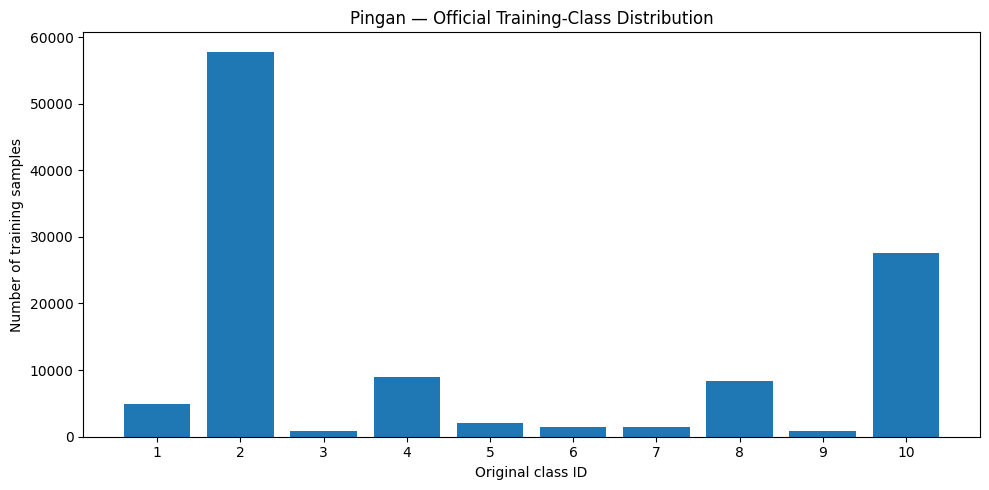

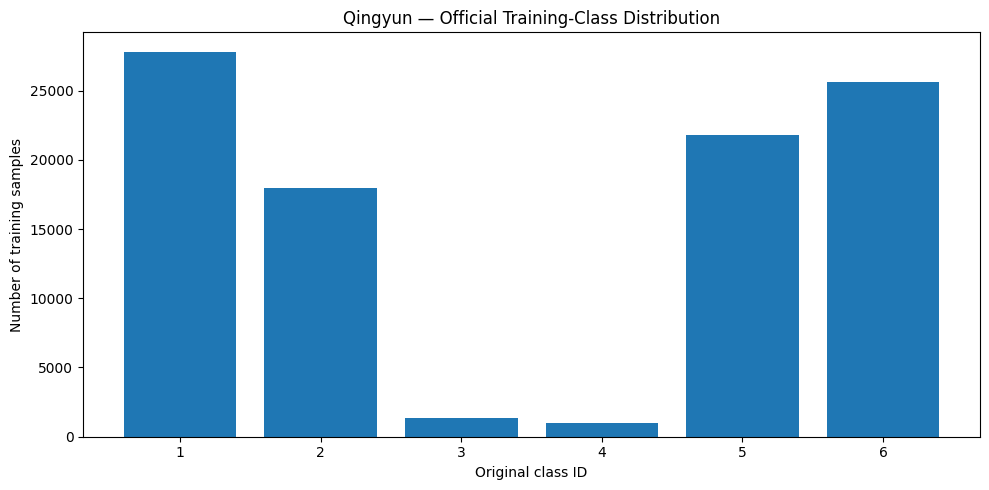

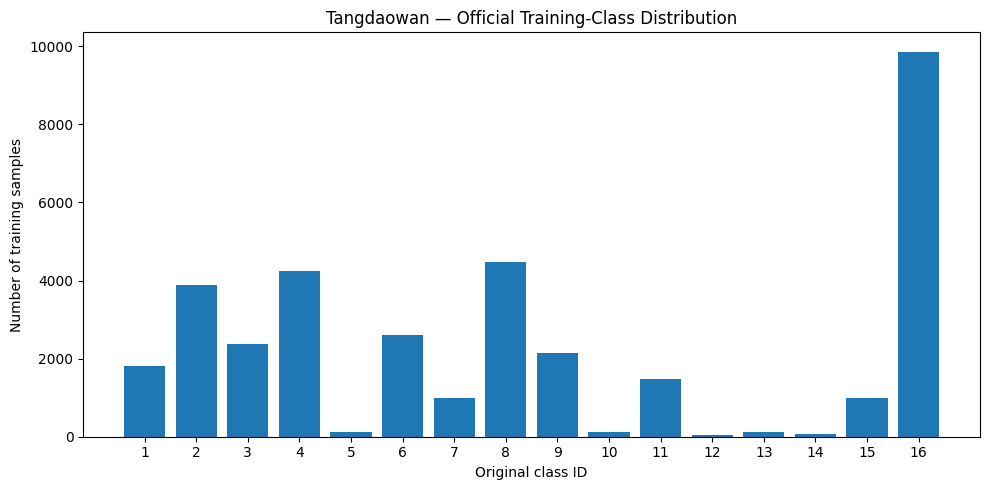

In [30]:
# ============================================================
# CELL 34 — PLOT OFFICIAL TRAINING CLASS DISTRIBUTIONS
# ============================================================

for dataset_name, count_df in official_count_tables.items():

    plt.figure(figsize=(10, 5))

    plt.bar(
        count_df["class_id"].astype(str),
        count_df["official_train_count"]
    )

    plt.title(
        f"{dataset_name} — Official Training-Class Distribution"
    )

    plt.xlabel("Original class ID")
    plt.ylabel("Number of training samples")

    plt.tight_layout()
    plt.show()

In [31]:
# ============================================================
# CELL 35 — PRE-SPLIT SUMMARY
# ============================================================

print("=" * 90)
print("PRE-SPLIT DATA SUMMARY")
print("=" * 90)

for dataset_name in DATASETS:

    stats = official_imbalance_stats[dataset_name]

    print(f"\n{dataset_name.upper()}")
    print("-" * 55)

    print(
        "Evaluation classes :",
        DATASETS[dataset_name]["evaluation_classes"]
    )

    print(
        "Official train     :",
        len(
            OFFICIAL_SPLITS[dataset_name][
                "train_flat_indices"
            ]
        )
    )

    print(
        "Official test      :",
        len(
            OFFICIAL_SPLITS[dataset_name][
                "test_flat_indices"
            ]
        )
    )

    print(
        f"Largest class      : "
        f"{stats['largest_class']} "
        f"({stats['largest_count']} samples)"
    )

    print(
        f"Smallest class     : "
        f"{stats['smallest_class']} "
        f"({stats['smallest_count']} samples)"
    )

    print(
        f"Official IR        : "
        f"{stats['imbalance_ratio']:.2f}:1"
    )

print("\n" + "=" * 90)
print("READY FOR FIXED 70/30 TRAIN–VALIDATION SPLIT")
print("=" * 90)

PRE-SPLIT DATA SUMMARY

PINGAN
-------------------------------------------------------
Evaluation classes : 10
Official train     : 114099
Official test      : 1026838
Largest class      : 2 (57811 samples)
Smallest class     : 9 (814 samples)
Official IR        : 71.02:1

QINGYUN
-------------------------------------------------------
Evaluation classes : 6
Official train     : 95492
Official test      : 859401
Largest class      : 1 (27817 samples)
Smallest class     : 4 (977 samples)
Official IR        : 28.47:1

TANGDAOWAN
-------------------------------------------------------
Evaluation classes : 16
Official train     : 35372
Official test      : 469917
Largest class      : 16 (9863 samples)
Smallest class     : 12 (52 samples)
Official IR        : 189.67:1

READY FOR FIXED 70/30 TRAIN–VALIDATION SPLIT


## Fixed 70/30 Train–Validation Split

The official QUH test masks remain completely untouched.

For each dataset, the official training centers are divided into:

- **70% actual training**
- **30% validation**

The split is:

- stratified by class;
- generated only from the official training mask;
- fixed using `random_state = 2026`;
- reused by every competing method.

The model-training seeds (`42`, `123`, and `3407`) do not change this split.

In [32]:
# ============================================================
# CELL 37 — DEFINE FIXED STRATIFIED SPLIT FUNCTION
# ============================================================

def create_fixed_train_validation_split(
    flat_indices,
    original_labels,
    validation_fraction=VALIDATION_FRACTION,
    split_seed=VALIDATION_SPLIT_SEED
):
    """
    Split official training centers into fixed actual-training
    and validation subsets using class stratification.
    """

    (
        train_indices,
        val_indices,
        train_labels,
        val_labels
    ) = train_test_split(
        flat_indices,
        original_labels,
        test_size=validation_fraction,
        random_state=split_seed,
        stratify=original_labels,
        shuffle=True
    )

    # Sort by flat index for deterministic storage/readability.
    train_order = np.argsort(train_indices)
    val_order = np.argsort(val_indices)

    train_indices = train_indices[train_order]
    train_labels = train_labels[train_order]

    val_indices = val_indices[val_order]
    val_labels = val_labels[val_order]

    return {
        "train_indices": train_indices,
        "train_labels_original": train_labels,
        "val_indices": val_indices,
        "val_labels_original": val_labels,
    }


print("Fixed stratified train-validation function created.")

Fixed stratified train-validation function created.


In [33]:
# ============================================================
# CELL 38 — GENERATE FIXED TRAIN / VALIDATION SPLITS
# ============================================================

FIXED_SPLITS = {}

for dataset_name, official_split in OFFICIAL_SPLITS.items():

    FIXED_SPLITS[dataset_name] = (
        create_fixed_train_validation_split(
            flat_indices=official_split[
                "train_flat_indices"
            ],
            original_labels=official_split[
                "train_labels_original"
            ],
        )
    )

    n_train = len(
        FIXED_SPLITS[dataset_name]["train_indices"]
    )

    n_val = len(
        FIXED_SPLITS[dataset_name]["val_indices"]
    )

    n_test = len(
        OFFICIAL_SPLITS[dataset_name][
            "test_flat_indices"
        ]
    )

    print(
        f"{dataset_name:12s} | "
        f"Actual train: {n_train:7d} | "
        f"Validation: {n_val:7d} | "
        f"Test: {n_test:7d}"
    )

Pingan       | Actual train:   79869 | Validation:   34230 | Test: 1026838
Qingyun      | Actual train:   66844 | Validation:   28648 | Test:  859401
Tangdaowan   | Actual train:   24760 | Validation:   10612 | Test:  469917


In [34]:
# ============================================================
# CELL 39 — PER-CLASS TRAIN / VALIDATION COUNTS
# ============================================================

split_count_tables = {}

for dataset_name in DATASETS:

    evaluation_classes = DATASETS[
        dataset_name
    ]["evaluation_class_ids"]

    official_train_labels = OFFICIAL_SPLITS[
        dataset_name
    ]["train_labels_original"]

    actual_train_labels = FIXED_SPLITS[
        dataset_name
    ]["train_labels_original"]

    val_labels = FIXED_SPLITS[
        dataset_name
    ]["val_labels_original"]

    records = []

    for class_id in evaluation_classes:

        official_count = int(
            np.sum(official_train_labels == class_id)
        )

        actual_train_count = int(
            np.sum(actual_train_labels == class_id)
        )

        val_count = int(
            np.sum(val_labels == class_id)
        )

        records.append({
            "class_id": class_id,
            "official_train": official_count,
            "actual_train_70pct": actual_train_count,
            "validation_30pct": val_count,
            "reconstructed_total":
                actual_train_count + val_count,
        })

    split_df = pd.DataFrame(records)

    split_count_tables[dataset_name] = split_df

    print("=" * 90)
    print(
        f"{dataset_name.upper()} — FIXED 70/30 CLASS SPLIT"
    )
    print("=" * 90)

    display(split_df)

    print()

PINGAN — FIXED 70/30 CLASS SPLIT


,class_id,official_train,actual_train_70pct,validation_30pct,reconstructed_total
0,1,4893,3425,1468,4893
1,2,57811,40468,17343,57811
2,3,835,585,250,835
3,4,8899,6229,2670,8899
4,5,2076,1453,623,2076
5,6,1409,986,423,1409
6,7,1398,979,419,1398
7,8,8312,5818,2494,8312
8,9,814,570,244,814
9,10,27652,19356,8296,27652



QINGYUN — FIXED 70/30 CLASS SPLIT


,class_id,official_train,actual_train_70pct,validation_30pct,reconstructed_total
0,1,27817,19472,8345,27817
1,2,17951,12565,5386,17951
2,3,1380,966,414,1380
3,4,977,684,293,977
4,5,21774,15242,6532,21774
5,6,25593,17915,7678,25593



TANGDAOWAN — FIXED 70/30 CLASS SPLIT


,class_id,official_train,actual_train_70pct,validation_30pct,reconstructed_total
0,1,1816,1271,545,1816
1,2,3890,2723,1167,3890
2,3,2383,1668,715,2383
3,4,4248,2974,1274,4248
4,5,130,91,39,130
5,6,2598,1819,779,2598
6,7,989,692,297,989
7,8,4486,3140,1346,4486
8,9,2148,1504,644,2148
9,10,124,87,37,124


In [35]:
# ============================================================
# CELL 40 — VALIDATE FIXED 70/30 SPLIT
# ============================================================

split_validation_results = {}

print("=" * 95)
print("FIXED TRAIN / VALIDATION / TEST INTEGRITY AUDIT")
print("=" * 95)

for dataset_name in DATASETS:

    official_train = OFFICIAL_SPLITS[
        dataset_name
    ]["train_flat_indices"]

    test_indices = OFFICIAL_SPLITS[
        dataset_name
    ]["test_flat_indices"]

    train_indices = FIXED_SPLITS[
        dataset_name
    ]["train_indices"]

    val_indices = FIXED_SPLITS[
        dataset_name
    ]["val_indices"]

    # --------------------------------------------------------
    # Pairwise overlap
    # --------------------------------------------------------

    train_val_overlap = len(
        np.intersect1d(train_indices, val_indices)
    )

    train_test_overlap = len(
        np.intersect1d(train_indices, test_indices)
    )

    val_test_overlap = len(
        np.intersect1d(val_indices, test_indices)
    )

    # --------------------------------------------------------
    # Completeness
    # --------------------------------------------------------

    reconstructed = np.sort(
        np.concatenate([
            train_indices,
            val_indices
        ])
    )

    official_sorted = np.sort(official_train)

    complete = np.array_equal(
        reconstructed,
        official_sorted
    )

    # --------------------------------------------------------
    # Class coverage
    # --------------------------------------------------------

    expected_classes = set(
        DATASETS[dataset_name][
            "evaluation_class_ids"
        ]
    )

    train_classes = set(
        np.unique(
            FIXED_SPLITS[dataset_name][
                "train_labels_original"
            ]
        ).tolist()
    )

    val_classes = set(
        np.unique(
            FIXED_SPLITS[dataset_name][
                "val_labels_original"
            ]
        ).tolist()
    )

    train_has_all_classes = (
        train_classes == expected_classes
    )

    val_has_all_classes = (
        val_classes == expected_classes
    )

    overall_pass = (
        train_val_overlap == 0
        and train_test_overlap == 0
        and val_test_overlap == 0
        and complete
        and train_has_all_classes
        and val_has_all_classes
    )

    split_validation_results[dataset_name] = {
        "train_val_overlap": train_val_overlap,
        "train_test_overlap": train_test_overlap,
        "val_test_overlap": val_test_overlap,
        "complete": complete,
        "train_has_all_classes": train_has_all_classes,
        "val_has_all_classes": val_has_all_classes,
        "passed": overall_pass,
    }

    print(f"\n{dataset_name.upper()}")
    print("-" * 70)

    print(
        f"Train ∩ Validation : {train_val_overlap}"
    )

    print(
        f"Train ∩ Test       : {train_test_overlap}"
    )

    print(
        f"Validation ∩ Test  : {val_test_overlap}"
    )

    print(
        "Train + Val reconstruct official train :",
        "PASS" if complete else "FAIL"
    )

    print(
        "Actual train contains every class       :",
        "PASS" if train_has_all_classes else "FAIL"
    )

    print(
        "Validation contains every class         :",
        "PASS" if val_has_all_classes else "FAIL"
    )

    print(
        "STATUS                                  :",
        "PASS" if overall_pass else "FAIL"
    )


print("\n" + "=" * 95)

all_pass = all(
    result["passed"]
    for result in split_validation_results.values()
)

print(
    "OVERALL FIXED-SPLIT STATUS:",
    "PASS" if all_pass else "FAIL"
)

print("=" * 95)

FIXED TRAIN / VALIDATION / TEST INTEGRITY AUDIT

PINGAN
----------------------------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
Train + Val reconstruct official train : PASS
Actual train contains every class       : PASS
Validation contains every class         : PASS
STATUS                                  : PASS

QINGYUN
----------------------------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
Train + Val reconstruct official train : PASS
Actual train contains every class       : PASS
Validation contains every class         : PASS
STATUS                                  : PASS

TANGDAOWAN
----------------------------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0
Train + Val reconstruct official train : PASS
Actual train contains every class       : PASS
Validation contains every class     

In [36]:
# ============================================================
# CELL 41 — FIXED-SPLIT REPRODUCIBILITY TEST
# ============================================================

split_reproducibility_results = {}

print("=" * 95)
print("FIXED 70/30 SPLIT — REPRODUCIBILITY TEST")
print("=" * 95)

for dataset_name, official_split in OFFICIAL_SPLITS.items():

    regenerated = create_fixed_train_validation_split(
        flat_indices=official_split["train_flat_indices"],
        original_labels=official_split["train_labels_original"],
        validation_fraction=VALIDATION_FRACTION,
        split_seed=VALIDATION_SPLIT_SEED
    )

    original = FIXED_SPLITS[dataset_name]

    train_indices_same = np.array_equal(
        original["train_indices"],
        regenerated["train_indices"]
    )

    train_labels_same = np.array_equal(
        original["train_labels_original"],
        regenerated["train_labels_original"]
    )

    val_indices_same = np.array_equal(
        original["val_indices"],
        regenerated["val_indices"]
    )

    val_labels_same = np.array_equal(
        original["val_labels_original"],
        regenerated["val_labels_original"]
    )

    overall_pass = (
        train_indices_same
        and train_labels_same
        and val_indices_same
        and val_labels_same
    )

    split_reproducibility_results[dataset_name] = overall_pass

    print(f"\n{dataset_name.upper()}")
    print("-" * 65)

    print(
        "Training indices identical   :",
        "PASS" if train_indices_same else "FAIL"
    )

    print(
        "Training labels identical    :",
        "PASS" if train_labels_same else "FAIL"
    )

    print(
        "Validation indices identical :",
        "PASS" if val_indices_same else "FAIL"
    )

    print(
        "Validation labels identical  :",
        "PASS" if val_labels_same else "FAIL"
    )

    print(
        "STATUS                       :",
        "PASS" if overall_pass else "FAIL"
    )


print("\n" + "=" * 95)

all_reproducible = all(
    split_reproducibility_results.values()
)

print(
    "OVERALL REPRODUCIBILITY STATUS:",
    "PASS" if all_reproducible else "FAIL"
)

print("=" * 95)

FIXED 70/30 SPLIT — REPRODUCIBILITY TEST

PINGAN
-----------------------------------------------------------------
Training indices identical   : PASS
Training labels identical    : PASS
Validation indices identical : PASS
Validation labels identical  : PASS
STATUS                       : PASS

QINGYUN
-----------------------------------------------------------------
Training indices identical   : PASS
Training labels identical    : PASS
Validation indices identical : PASS
Validation labels identical  : PASS
STATUS                       : PASS

TANGDAOWAN
-----------------------------------------------------------------
Training indices identical   : PASS
Training labels identical    : PASS
Validation indices identical : PASS
Validation labels identical  : PASS
STATUS                       : PASS

OVERALL REPRODUCIBILITY STATUS: PASS


In [37]:
# ============================================================
# CELL 42 — FINAL ACTUAL-TRAINING STATISTICS
# ============================================================

FINAL_CLASS_STATS = {}
final_imbalance_records = []

for dataset_name in DATASETS:

    split_df = split_count_tables[dataset_name].copy()

    counts = split_df["actual_train_70pct"].to_numpy()

    largest_idx = np.argmax(counts)
    smallest_idx = np.argmin(counts)

    largest_class = int(
        split_df.iloc[largest_idx]["class_id"]
    )

    smallest_class = int(
        split_df.iloc[smallest_idx]["class_id"]
    )

    largest_count = int(counts[largest_idx])
    smallest_count = int(counts[smallest_idx])

    imbalance_ratio = (
        largest_count / smallest_count
    )

    FINAL_CLASS_STATS[dataset_name] = {
        "largest_class": largest_class,
        "largest_count": largest_count,
        "smallest_class": smallest_class,
        "smallest_count": smallest_count,
        "imbalance_ratio": imbalance_ratio,
    }

    final_imbalance_records.append({
        "dataset": dataset_name,
        "largest_class": largest_class,
        "largest_count": largest_count,
        "smallest_class": smallest_class,
        "smallest_count": smallest_count,
        "final_IR": imbalance_ratio,
    })


final_imbalance_df = pd.DataFrame(
    final_imbalance_records
)

print("=" * 90)
print("FINAL 70% ACTUAL-TRAINING IMBALANCE")
print("=" * 90)

display(
    final_imbalance_df.round({
        "final_IR": 2
    })
)

FINAL 70% ACTUAL-TRAINING IMBALANCE


,dataset,largest_class,largest_count,smallest_class,smallest_count,final_IR
0,Pingan,2,40468,9,570,71.00
1,Qingyun,1,19472,4,684,28.47
2,Tangdaowan,16,6904,12,36,191.78


In [38]:
# ============================================================
# CELL 43 — FINAL IMBALANCE-RATIO SANITY CHECK
# ============================================================

BLUEPRINT_IR_TARGETS = {
    "Pingan": 71.00,
    "Qingyun": 28.47,
    "Tangdaowan": 191.78,
}

IR_TOLERANCE = 0.05

print("=" * 90)
print("FINAL IMBALANCE-RATIO SANITY CHECK")
print("=" * 90)

ir_sanity_results = {}

for dataset_name in DATASETS:

    observed = FINAL_CLASS_STATS[
        dataset_name
    ]["imbalance_ratio"]

    target = BLUEPRINT_IR_TARGETS[
        dataset_name
    ]

    difference = abs(
        observed - target
    )

    passed = difference <= IR_TOLERANCE

    ir_sanity_results[dataset_name] = passed

    print(
        f"{dataset_name:12s} | "
        f"Observed = {observed:8.2f}:1 | "
        f"Target ≈ {target:8.2f}:1 | "
        f"{'PASS' if passed else 'CHECK'}"
    )

print()

if all(ir_sanity_results.values()):
    print("FINAL IR SANITY STATUS: PASS")
else:
    print("FINAL IR SANITY STATUS: REVIEW")

FINAL IMBALANCE-RATIO SANITY CHECK
Pingan       | Observed =    71.00:1 | Target ≈    71.00:1 | PASS
Qingyun      | Observed =    28.47:1 | Target ≈    28.47:1 | PASS
Tangdaowan   | Observed =   191.78:1 | Target ≈   191.78:1 | PASS

FINAL IR SANITY STATUS: PASS


## Head, Medium, and Tail Class Definition

Long-tail groups are defined **before any model results are observed**.

For each dataset:

1. Classes are sorted by their **actual 70% training count** from lowest
   frequency to highest frequency.
2. Let:

   `q = floor(K / 3)`

3. The groups are defined as:

   - **Tail** = lowest-frequency `q` classes
   - **Head** = highest-frequency `q` classes
   - **Medium** = all remaining classes

Therefore:

- Pingan: `K = 10` → 3 Tail / 4 Medium / 3 Head
- Qingyun: `K = 6` → 2 Tail / 2 Medium / 2 Head
- Tangdaowan public split: `K = 16` → 5 Tail / 6 Medium / 5 Head

Group membership depends only on training frequency and is frozen before
model evaluation.

In [39]:
# ============================================================
# CELL 45 — DEFINE HEAD / MEDIUM / TAIL GROUP FUNCTION
# ============================================================

def assign_frequency_groups(class_ids, class_counts):
    """
    Assign Tail / Medium / Head groups using the frozen
    rank-based rule:

        q = floor(K / 3)

    Tail   = q least frequent classes
    Head   = q most frequent classes
    Medium = remaining classes
    """

    class_ids = np.asarray(class_ids)
    class_counts = np.asarray(class_counts)

    if len(class_ids) != len(class_counts):
        raise ValueError(
            "class_ids and class_counts must have equal length."
        )

    K = len(class_ids)
    q = K // 3

    # Stable deterministic ordering:
    # primary key = count
    # secondary key = class ID
    sorted_order = np.lexsort(
        (class_ids, class_counts)
    )

    sorted_classes = class_ids[sorted_order]

    tail_classes = sorted(
        sorted_classes[:q].tolist()
    )

    head_classes = sorted(
        sorted_classes[-q:].tolist()
    )

    medium_classes = sorted(
        sorted_classes[q:-q].tolist()
    )

    group_mapping = {}

    for class_id in tail_classes:
        group_mapping[int(class_id)] = "Tail"

    for class_id in medium_classes:
        group_mapping[int(class_id)] = "Medium"

    for class_id in head_classes:
        group_mapping[int(class_id)] = "Head"

    return {
        "q": q,
        "tail_classes": tail_classes,
        "medium_classes": medium_classes,
        "head_classes": head_classes,
        "group_mapping": group_mapping,
    }


print("Frequency-group assignment function created successfully.")

Frequency-group assignment function created successfully.


In [40]:
# ============================================================
# CELL 46 — ASSIGN AND FREEZE HEAD / MEDIUM / TAIL GROUPS
# ============================================================

FREQUENCY_GROUPS = {}
frequency_group_tables = {}

for dataset_name in DATASETS:

    split_df = split_count_tables[
        dataset_name
    ].copy()

    result = assign_frequency_groups(
        class_ids=split_df["class_id"].to_numpy(),
        class_counts=split_df[
            "actual_train_70pct"
        ].to_numpy()
    )

    FREQUENCY_GROUPS[dataset_name] = result

    split_df["frequency_group"] = (
        split_df["class_id"]
        .map(result["group_mapping"])
    )

    # Rank from rarest = 1
    split_df["frequency_rank_rarest_first"] = (
        split_df["actual_train_70pct"]
        .rank(
            method="first",
            ascending=True
        )
        .astype(int)
    )

    frequency_group_tables[
        dataset_name
    ] = split_df

    print("=" * 90)
    print(
        f"{dataset_name.upper()} — "
        f"HEAD / MEDIUM / TAIL GROUPS"
    )
    print("=" * 90)

    print(
        f"K = {len(split_df)}, "
        f"q = {result['q']}"
    )

    print(
        "Tail classes   :",
        result["tail_classes"]
    )

    print(
        "Medium classes :",
        result["medium_classes"]
    )

    print(
        "Head classes   :",
        result["head_classes"]
    )

    print()

    display(
        split_df[
            [
                "class_id",
                "actual_train_70pct",
                "frequency_rank_rarest_first",
                "frequency_group",
            ]
        ].sort_values(
            "actual_train_70pct"
        )
    )

    print()

PINGAN — HEAD / MEDIUM / TAIL GROUPS
K = 10, q = 3
Tail classes   : [3, 7, 9]
Medium classes : [1, 5, 6, 8]
Head classes   : [2, 4, 10]



,class_id,actual_train_70pct,frequency_rank_rarest_first,frequency_group
8,9,570,1,Tail
2,3,585,2,Tail
6,7,979,3,Tail
5,6,986,4,Medium
4,5,1453,5,Medium
0,1,3425,6,Medium
7,8,5818,7,Medium
3,4,6229,8,Head
9,10,19356,9,Head
1,2,40468,10,Head



QINGYUN — HEAD / MEDIUM / TAIL GROUPS
K = 6, q = 2
Tail classes   : [3, 4]
Medium classes : [2, 5]
Head classes   : [1, 6]



,class_id,actual_train_70pct,frequency_rank_rarest_first,frequency_group
3,4,684,1,Tail
2,3,966,2,Tail
1,2,12565,3,Medium
4,5,15242,4,Medium
5,6,17915,5,Head
0,1,19472,6,Head



TANGDAOWAN — HEAD / MEDIUM / TAIL GROUPS
K = 16, q = 5
Tail classes   : [5, 10, 12, 13, 14]
Medium classes : [1, 3, 7, 9, 11, 15]
Head classes   : [2, 4, 6, 8, 16]



,class_id,actual_train_70pct,frequency_rank_rarest_first,frequency_group
11,12,36,1,Tail
13,14,43,2,Tail
12,13,83,3,Tail
9,10,87,4,Tail
4,5,91,5,Tail
14,15,685,6,Medium
6,7,692,7,Medium
10,11,1040,8,Medium
0,1,1271,9,Medium
8,9,1504,10,Medium


In [41]:
# ============================================================
# CELL 47 — COMPUTE LTLC TRAINING PRIORS AND RARITY SCORES
# ============================================================

EPSILON = 1e-12

LTLC_CLASS_STATS = {}

for dataset_name in DATASETS:

    group_df = frequency_group_tables[
        dataset_name
    ].copy()

    class_ids = group_df[
        "class_id"
    ].to_numpy(dtype=int)

    counts = group_df[
        "actual_train_70pct"
    ].to_numpy(dtype=np.int64)

    # --------------------------------------------------------
    # Empirical training prior
    # --------------------------------------------------------

    total_train = counts.sum()

    priors = (
        counts.astype(np.float64)
        / float(total_train)
    )

    # --------------------------------------------------------
    # Normalized log-frequency rarity
    # --------------------------------------------------------

    n_max = counts.max()
    n_min = counts.min()

    if n_max == n_min:

        rarity = np.zeros(
            len(counts),
            dtype=np.float64
        )

    else:

        rarity = (
            np.log(n_max + EPSILON)
            - np.log(counts + EPSILON)
        ) / (
            np.log(n_max + EPSILON)
            - np.log(n_min + EPSILON)
        )

    stats_df = pd.DataFrame({
        "class_id": class_ids,
        "train_count": counts,
        "prior": priors,
        "rarity": rarity,
    })

    stats_df["frequency_group"] = (
        stats_df["class_id"].map(
            FREQUENCY_GROUPS[
                dataset_name
            ]["group_mapping"]
        )
    )

    LTLC_CLASS_STATS[
        dataset_name
    ] = stats_df

    print("=" * 90)
    print(
        f"{dataset_name.upper()} — "
        f"LTLC DATA-DEPENDENT CLASS STATISTICS"
    )
    print("=" * 90)

    display(
        stats_df.sort_values(
            "train_count"
        ).reset_index(drop=True)
    )

    print()

PINGAN — LTLC DATA-DEPENDENT CLASS STATISTICS


,class_id,train_count,prior,rarity,frequency_group
0,9,570,0.007137,1.000000,Tail
1,3,585,0.007324,0.993906,Tail
2,7,979,0.012258,0.873108,Tail
3,6,986,0.012345,0.871436,Medium
4,5,1453,0.018192,0.780476,Medium
5,1,3425,0.042883,0.579316,Medium
6,8,5818,0.072844,0.455014,Medium
7,4,6229,0.077990,0.439000,Head
8,10,19356,0.242347,0.173017,Head
9,2,40468,0.506680,0.000000,Head



QINGYUN — LTLC DATA-DEPENDENT CLASS STATISTICS


,class_id,train_count,prior,rarity,frequency_group
0,4,684,0.010233,1.000000,Tail
1,3,966,0.014452,0.896916,Tail
2,2,12565,0.187975,0.130813,Medium
3,5,15242,0.228023,0.073138,Medium
4,6,17915,0.268012,0.024886,Head
5,1,19472,0.291305,0.000000,Head



TANGDAOWAN — LTLC DATA-DEPENDENT CLASS STATISTICS


,class_id,train_count,prior,rarity,frequency_group
0,12,36,0.001454,1.000000,Tail
1,14,43,0.001737,0.966197,Tail
2,13,83,0.003352,0.841083,Tail
3,10,87,0.003514,0.832129,Tail
4,5,91,0.003675,0.823577,Tail
5,15,685,0.027666,0.439553,Medium
6,7,692,0.027948,0.437618,Medium
7,11,1040,0.042003,0.360114,Medium
8,1,1271,0.051333,0.321954,Medium
9,9,1504,0.060743,0.289931,Medium


In [42]:
# ============================================================
# CELL 48 — VALIDATE PRIORS / RARITY / FREQUENCY GROUPS
# ============================================================

ltlc_stats_validation = {}

print("=" * 95)
print("LTLC CLASS-STATISTICS VALIDATION")
print("=" * 95)

for dataset_name, stats_df in LTLC_CLASS_STATS.items():

    priors = stats_df[
        "prior"
    ].to_numpy()

    rarity = stats_df[
        "rarity"
    ].to_numpy()

    counts = stats_df[
        "train_count"
    ].to_numpy()

    # --------------------------------------------------------
    # Checks
    # --------------------------------------------------------

    prior_sum_pass = np.isclose(
        priors.sum(),
        1.0,
        atol=1e-12
    )

    priors_positive = np.all(
        priors > 0
    )

    rarity_range_pass = np.all(
        (rarity >= -1e-12)
        &
        (rarity <= 1 + 1e-12)
    )

    head_rarity_pass = np.isclose(
        rarity[np.argmax(counts)],
        0.0,
        atol=1e-10
    )

    tail_rarity_pass = np.isclose(
        rarity[np.argmin(counts)],
        1.0,
        atol=1e-10
    )

    expected_k = DATASETS[
        dataset_name
    ]["evaluation_classes"]

    all_classes_present = (
        len(stats_df) == expected_k
    )

    no_missing_groups = (
        stats_df[
            "frequency_group"
        ].notna().all()
    )

    overall_pass = all([
        prior_sum_pass,
        priors_positive,
        rarity_range_pass,
        head_rarity_pass,
        tail_rarity_pass,
        all_classes_present,
        no_missing_groups,
    ])

    ltlc_stats_validation[
        dataset_name
    ] = overall_pass

    print(f"\n{dataset_name.upper()}")
    print("-" * 70)

    print(
        f"Prior sum                 : "
        f"{priors.sum():.12f}"
    )

    print(
        "Priors sum to 1           :",
        "PASS" if prior_sum_pass else "FAIL"
    )

    print(
        "All priors > 0            :",
        "PASS" if priors_positive else "FAIL"
    )

    print(
        "All rarity values in [0,1]:",
        "PASS" if rarity_range_pass else "FAIL"
    )

    print(
        "Largest class rarity = 0  :",
        "PASS" if head_rarity_pass else "FAIL"
    )

    print(
        "Smallest class rarity = 1 :",
        "PASS" if tail_rarity_pass else "FAIL"
    )

    print(
        "All evaluation classes    :",
        "PASS" if all_classes_present else "FAIL"
    )

    print(
        "Every class has H/M/T group:",
        "PASS" if no_missing_groups else "FAIL"
    )

    print(
        "STATUS                     :",
        "PASS" if overall_pass else "FAIL"
    )


print("\n" + "=" * 95)

all_ltlc_stats_pass = all(
    ltlc_stats_validation.values()
)

print(
    "OVERALL LTLC CLASS-STATISTICS STATUS:",
    "PASS" if all_ltlc_stats_pass else "FAIL"
)

print("=" * 95)

LTLC CLASS-STATISTICS VALIDATION

PINGAN
----------------------------------------------------------------------
Prior sum                 : 1.000000000000
Priors sum to 1           : PASS
All priors > 0            : PASS
All rarity values in [0,1]: PASS
Largest class rarity = 0  : PASS
Smallest class rarity = 1 : PASS
All evaluation classes    : PASS
Every class has H/M/T group: PASS
STATUS                     : PASS

QINGYUN
----------------------------------------------------------------------
Prior sum                 : 1.000000000000
Priors sum to 1           : PASS
All priors > 0            : PASS
All rarity values in [0,1]: PASS
Largest class rarity = 0  : PASS
Smallest class rarity = 1 : PASS
All evaluation classes    : PASS
Every class has H/M/T group: PASS
STATUS                     : PASS

TANGDAOWAN
----------------------------------------------------------------------
Prior sum                 : 1.000000000000
Priors sum to 1           : PASS
All priors > 0            : PAS

## Freeze Immutable Research Artifacts

The dataset audit and fixed train-validation split have now passed all
mandatory integrity checks.

The following artifacts will now be saved permanently to Google Drive:

- actual-training center indices;
- validation center indices;
- official test center indices;
- original dataset labels;
- model labels (`0 ... K-1`);
- class-frequency statistics;
- empirical training priors;
- LTLC rarity scores;
- Head / Medium / Tail assignments;
- public-split protocol metadata;
- deterministic SHA-256 hashes.

These files become the canonical data protocol for every later notebook.

Later experiments must load these saved artifacts rather than creating
new train-validation splits.

In [43]:
# ============================================================
# CELL 50 — CREATE AND VALIDATE MODEL LABELS
# ============================================================

MODEL_SPLITS = {}

print("=" * 90)
print("MODEL-LABEL CONVERSION")
print("=" * 90)

for dataset_name in DATASETS:

    mapping = CLASS_MAPPINGS[
        dataset_name
    ]["original_to_model"]

    # --------------------------------------------------------
    # Original labels
    # --------------------------------------------------------

    train_original = FIXED_SPLITS[
        dataset_name
    ]["train_labels_original"]

    val_original = FIXED_SPLITS[
        dataset_name
    ]["val_labels_original"]

    test_original = OFFICIAL_SPLITS[
        dataset_name
    ]["test_labels_original"]

    # --------------------------------------------------------
    # Convert original class IDs -> model IDs
    # --------------------------------------------------------

    train_model = np.array(
        [mapping[int(x)] for x in train_original],
        dtype=np.int64
    )

    val_model = np.array(
        [mapping[int(x)] for x in val_original],
        dtype=np.int64
    )

    test_model = np.array(
        [mapping[int(x)] for x in test_original],
        dtype=np.int64
    )

    K = DATASETS[
        dataset_name
    ]["evaluation_classes"]

    # --------------------------------------------------------
    # Validate model labels
    # --------------------------------------------------------

    expected_model_classes = set(
        range(K)
    )

    train_classes = set(
        np.unique(train_model).tolist()
    )

    val_classes = set(
        np.unique(val_model).tolist()
    )

    test_classes = set(
        np.unique(test_model).tolist()
    )

    train_pass = (
        train_classes == expected_model_classes
    )

    val_pass = (
        val_classes == expected_model_classes
    )

    test_pass = (
        test_classes == expected_model_classes
    )

    if not (
        train_pass
        and val_pass
        and test_pass
    ):
        raise ValueError(
            f"{dataset_name}: model-label conversion failed."
        )

    MODEL_SPLITS[dataset_name] = {
        "train_labels_model": train_model,
        "val_labels_model": val_model,
        "test_labels_model": test_model,
    }

    print(f"\n{dataset_name.upper()}")
    print("-" * 60)

    print(
        f"Expected model IDs : "
        f"0 ... {K - 1}"
    )

    print(
        "Train classes      :",
        sorted(train_classes)
    )

    print(
        "Validation classes :",
        sorted(val_classes)
    )

    print(
        "Test classes       :",
        sorted(test_classes)
    )

    print("STATUS             : PASS")

print("\nModel-label conversion complete.")

MODEL-LABEL CONVERSION

PINGAN
------------------------------------------------------------
Expected model IDs : 0 ... 9
Train classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Validation classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Test classes       : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
STATUS             : PASS

QINGYUN
------------------------------------------------------------
Expected model IDs : 0 ... 5
Train classes      : [0, 1, 2, 3, 4, 5]
Validation classes : [0, 1, 2, 3, 4, 5]
Test classes       : [0, 1, 2, 3, 4, 5]
STATUS             : PASS

TANGDAOWAN
------------------------------------------------------------
Expected model IDs : 0 ... 15
Train classes      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Validation classes : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Test classes       : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
STATUS             : PASS

Model-label conversion complete.


In [44]:
# ============================================================
# CELL 51 — SAVE IMMUTABLE SPLIT ARTIFACTS
# ============================================================

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

saved_split_paths = {}

for dataset_name in DATASETS:

    cfg = DATASETS[dataset_name]

    train_indices = FIXED_SPLITS[
        dataset_name
    ]["train_indices"].astype(np.int64)

    val_indices = FIXED_SPLITS[
        dataset_name
    ]["val_indices"].astype(np.int64)

    test_indices = OFFICIAL_SPLITS[
        dataset_name
    ]["test_flat_indices"].astype(np.int64)

    train_original = FIXED_SPLITS[
        dataset_name
    ]["train_labels_original"].astype(np.int64)

    val_original = FIXED_SPLITS[
        dataset_name
    ]["val_labels_original"].astype(np.int64)

    test_original = OFFICIAL_SPLITS[
        dataset_name
    ]["test_labels_original"].astype(np.int64)

    train_model = MODEL_SPLITS[
        dataset_name
    ]["train_labels_model"]

    val_model = MODEL_SPLITS[
        dataset_name
    ]["val_labels_model"]

    test_model = MODEL_SPLITS[
        dataset_name
    ]["test_labels_model"]

    output_path = (
        SPLIT_DIR /
        f"{dataset_name.lower()}_fixed_split_seed2026.npz"
    )

    np.savez_compressed(
        output_path,

        train_indices=train_indices,
        val_indices=val_indices,
        test_indices=test_indices,

        train_labels_original=train_original,
        val_labels_original=val_original,
        test_labels_original=test_original,

        train_labels_model=train_model,
        val_labels_model=val_model,
        test_labels_model=test_model,

        evaluation_class_ids=np.asarray(
            cfg["evaluation_class_ids"],
            dtype=np.int64
        ),

        full_gt_class_ids=np.asarray(
            cfg["full_gt_class_ids"],
            dtype=np.int64
        ),

        spatial_shape=np.asarray(
            cfg["cube_shape"][:2],
            dtype=np.int64
        ),

        spectral_bands=np.asarray(
            [cfg["cube_shape"][2]],
            dtype=np.int64
        ),

        validation_split_seed=np.asarray(
            [VALIDATION_SPLIT_SEED],
            dtype=np.int64
        ),

        validation_fraction=np.asarray(
            [VALIDATION_FRACTION],
            dtype=np.float64
        ),
    )

    saved_split_paths[
        dataset_name
    ] = output_path

    print(
        f"{dataset_name:12s} -> {output_path.name}"
    )

print("\nImmutable split artifacts saved successfully.")

Pingan       -> pingan_fixed_split_seed2026.npz
Qingyun      -> qingyun_fixed_split_seed2026.npz
Tangdaowan   -> tangdaowan_fixed_split_seed2026.npz

Immutable split artifacts saved successfully.


In [45]:
# ============================================================
# CELL 52 — GENERATE DETERMINISTIC SPLIT HASHES
# ============================================================

def sha256_array(array):
    """
    Compute a deterministic SHA-256 fingerprint including
    array shape, dtype, and raw bytes.
    """

    array = np.ascontiguousarray(array)

    hasher = hashlib.sha256()

    hasher.update(
        str(array.shape).encode("utf-8")
    )

    hasher.update(
        str(array.dtype).encode("utf-8")
    )

    hasher.update(
        array.tobytes()
    )

    return hasher.hexdigest()


SPLIT_HASHES = {}

for dataset_name in DATASETS:

    train_idx = FIXED_SPLITS[
        dataset_name
    ]["train_indices"].astype(np.int64)

    val_idx = FIXED_SPLITS[
        dataset_name
    ]["val_indices"].astype(np.int64)

    test_idx = OFFICIAL_SPLITS[
        dataset_name
    ]["test_flat_indices"].astype(np.int64)

    train_hash = sha256_array(train_idx)
    val_hash = sha256_array(val_idx)
    test_hash = sha256_array(test_idx)

    # Combined canonical split hash
    combined_hasher = hashlib.sha256()

    combined_hasher.update(
        train_hash.encode("utf-8")
    )

    combined_hasher.update(
        val_hash.encode("utf-8")
    )

    combined_hasher.update(
        test_hash.encode("utf-8")
    )

    combined_hash = (
        combined_hasher.hexdigest()
    )

    SPLIT_HASHES[dataset_name] = {
        "train_hash": train_hash,
        "validation_hash": val_hash,
        "test_hash": test_hash,
        "combined_split_hash": combined_hash,
    }

    print("=" * 80)
    print(dataset_name.upper())
    print("=" * 80)

    print(
        "Train hash      :",
        train_hash
    )

    print(
        "Validation hash :",
        val_hash
    )

    print(
        "Test hash       :",
        test_hash
    )

    print(
        "Combined hash   :",
        combined_hash
    )

    print()

PINGAN
Train hash      : 5a2d85a567a31330d34dce32526bef7a93c2e5401a0ab0d060a8bfe895f440a7
Validation hash : 852742b94a43c639d42cf06bbeb57f3b9226095ba5ec3df1d2def78149e51abb
Test hash       : b3d8922b8c3dc1e64af1ae1f575dccd60c1aa4210fde7cb7922a567a55051f36
Combined hash   : 738703dda7e55e69bef3eb8bfad5d30c34a82788d2732268cf94da3bc3085592

QINGYUN
Train hash      : 8b5a61bd8c04ecedd0c71a725fc97113b9b56e66a02ac344e3b8d9a6d7074a34
Validation hash : 345f7c3782401c4b19636b06b3dc27c7db2aed915c146a83b2f52beb13d03962
Test hash       : dc9e6c8e5387f2de84de0481f8f4e85cdcdcf05629ef85fe3584fefe86eae772
Combined hash   : 57607a2a614456e2a834e0bd4c8f2c315d5cca7e47658b900f5c2e5a6a030820

TANGDAOWAN
Train hash      : abf1d2ecb2c3a791ee8f15c04857fe08a6c5fae886b68c16116ff73aebd7b638
Validation hash : e2e657898dfa9a8e6ac1d6221482556214f1a0137055bc0bc8afbaded8d58655
Test hash       : 3b60496fcfd33c9f748c38a104217af0602b6b5558a84d1a2fc1048d3e888a74
Combined hash   : b5283f3a067b11adfc9fceabd0a59bfbcfafa5dde

In [46]:
# ============================================================
# CELL 53 — SAVE AUDIT TABLES AND PROTOCOL METADATA
# ============================================================

AUDIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Save general tables
# ------------------------------------------------------------

official_imbalance_df.to_csv(
    AUDIT_DIR / "official_imbalance_summary.csv",
    index=False
)

final_imbalance_df.to_csv(
    AUDIT_DIR / "final_training_imbalance_summary.csv",
    index=False
)

protocol_summary_df.to_csv(
    AUDIT_DIR / "public_split_protocol_summary.csv",
    index=False
)

# ------------------------------------------------------------
# Save per-dataset tables
# ------------------------------------------------------------

for dataset_name in DATASETS:

    slug = dataset_name.lower()

    official_count_tables[
        dataset_name
    ].to_csv(
        AUDIT_DIR /
        f"{slug}_official_class_counts.csv",
        index=False
    )

    split_count_tables[
        dataset_name
    ].to_csv(
        AUDIT_DIR /
        f"{slug}_fixed_70_30_counts.csv",
        index=False
    )

    frequency_group_tables[
        dataset_name
    ].to_csv(
        AUDIT_DIR /
        f"{slug}_frequency_groups.csv",
        index=False
    )

    LTLC_CLASS_STATS[
        dataset_name
    ].to_csv(
        AUDIT_DIR /
        f"{slug}_ltlc_class_statistics.csv",
        index=False
    )


# ------------------------------------------------------------
# JSON-safe conversion helper
# ------------------------------------------------------------

def json_safe(value):

    if isinstance(
        value,
        (np.integer,)
    ):
        return int(value)

    if isinstance(
        value,
        (np.floating,)
    ):
        return float(value)

    if isinstance(
        value,
        np.ndarray
    ):
        return value.tolist()

    if isinstance(
        value,
        Path
    ):
        return str(value)

    if isinstance(
        value,
        dict
    ):
        return {
            str(k): json_safe(v)
            for k, v in value.items()
        }

    if isinstance(
        value,
        (list, tuple)
    ):
        return [
            json_safe(v)
            for v in value
        ]

    return value


# ------------------------------------------------------------
# Protocol metadata
# ------------------------------------------------------------

protocol_metadata = {
    "project": "CSE498R LTLC",
    "protocol_version":
        "Experiment Blueprint v3.1 - audited public split",

    "timestamp":
        datetime.now().isoformat(),

    "validation_split_seed":
        VALIDATION_SPLIT_SEED,

    "validation_fraction":
        VALIDATION_FRACTION,

    "model_training_seeds":
        [42, 123, 3407],

    "datasets": {},

    "environment":
        environment_info,
}


for dataset_name in DATASETS:

    cfg = DATASETS[dataset_name]

    protocol_metadata[
        "datasets"
    ][dataset_name] = {

        "cube_shape":
            list(cfg["cube_shape"]),

        "cube_key":
            cfg["cube_key"],

        "gt_key":
            cfg["gt_key"],

        "train_key":
            cfg["train_key"],

        "test_key":
            cfg["test_key"],

        "full_gt_class_ids":
            cfg["full_gt_class_ids"],

        "evaluation_class_ids":
            cfg["evaluation_class_ids"],

        "evaluation_class_count":
            cfg["evaluation_classes"],

        "omitted_gt_classes":
            PUBLIC_SPLIT_PROTOCOL[
                dataset_name
            ]["omitted_from_public_split"],

        "patch_size":
            cfg["patch_size"],

        "pca_components":
            cfg["pca_components"],

        "class_mapping":
            CLASS_MAPPINGS[
                dataset_name
            ],

        "frequency_groups":
            FREQUENCY_GROUPS[
                dataset_name
            ],

        "split_hashes":
            SPLIT_HASHES[
                dataset_name
            ],
    }


metadata_path = (
    AUDIT_DIR /
    "notebook01_protocol_metadata.json"
)

with open(
    metadata_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(protocol_metadata),
        f,
        indent=2
    )


# ------------------------------------------------------------
# Environment information separately
# ------------------------------------------------------------

with open(
    AUDIT_DIR / "environment.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        json_safe(environment_info),
        f,
        indent=2
    )


print("=" * 80)
print("AUDIT ARTIFACTS SAVED")
print("=" * 80)

print(
    "Audit directory:",
    AUDIT_DIR
)

print(
    "Protocol metadata:",
    metadata_path.name
)

print("\nCSV and JSON audit files saved successfully.")

AUDIT ARTIFACTS SAVED
Audit directory: /content/drive/MyDrive/CSE498/LTLC/audit
Protocol metadata: notebook01_protocol_metadata.json

CSV and JSON audit files saved successfully.


In [47]:
# ============================================================
# CELL 54 — RELOAD SAVED SPLITS AND VERIFY
# ============================================================

reload_verification_results = {}

print("=" * 95)
print("SAVED SPLIT ARTIFACT — RELOAD VERIFICATION")
print("=" * 95)

for dataset_name, split_path in saved_split_paths.items():

    with np.load(
        split_path,
        allow_pickle=False
    ) as saved:

        saved_train = saved[
            "train_indices"
        ]

        saved_val = saved[
            "val_indices"
        ]

        saved_test = saved[
            "test_indices"
        ]

        saved_train_labels = saved[
            "train_labels_original"
        ]

        saved_val_labels = saved[
            "val_labels_original"
        ]

        saved_test_labels = saved[
            "test_labels_original"
        ]

    # --------------------------------------------------------
    # Compare against current canonical data
    # --------------------------------------------------------

    train_idx_pass = np.array_equal(
        saved_train,
        FIXED_SPLITS[
            dataset_name
        ]["train_indices"]
    )

    val_idx_pass = np.array_equal(
        saved_val,
        FIXED_SPLITS[
            dataset_name
        ]["val_indices"]
    )

    test_idx_pass = np.array_equal(
        saved_test,
        OFFICIAL_SPLITS[
            dataset_name
        ]["test_flat_indices"]
    )

    train_label_pass = np.array_equal(
        saved_train_labels,
        FIXED_SPLITS[
            dataset_name
        ]["train_labels_original"]
    )

    val_label_pass = np.array_equal(
        saved_val_labels,
        FIXED_SPLITS[
            dataset_name
        ]["val_labels_original"]
    )

    test_label_pass = np.array_equal(
        saved_test_labels,
        OFFICIAL_SPLITS[
            dataset_name
        ]["test_labels_original"]
    )

    # --------------------------------------------------------
    # Recompute combined hash after reload
    # --------------------------------------------------------

    train_hash = sha256_array(
        saved_train
    )

    val_hash = sha256_array(
        saved_val
    )

    test_hash = sha256_array(
        saved_test
    )

    combined_hasher = hashlib.sha256()

    combined_hasher.update(
        train_hash.encode("utf-8")
    )

    combined_hasher.update(
        val_hash.encode("utf-8")
    )

    combined_hasher.update(
        test_hash.encode("utf-8")
    )

    reloaded_combined_hash = (
        combined_hasher.hexdigest()
    )

    hash_pass = (
        reloaded_combined_hash
        ==
        SPLIT_HASHES[
            dataset_name
        ]["combined_split_hash"]
    )

    overall_pass = all([
        train_idx_pass,
        val_idx_pass,
        test_idx_pass,
        train_label_pass,
        val_label_pass,
        test_label_pass,
        hash_pass,
    ])

    reload_verification_results[
        dataset_name
    ] = overall_pass

    print(f"\n{dataset_name.upper()}")
    print("-" * 70)

    print(
        "Training indices    :",
        "PASS" if train_idx_pass else "FAIL"
    )

    print(
        "Validation indices  :",
        "PASS" if val_idx_pass else "FAIL"
    )

    print(
        "Test indices        :",
        "PASS" if test_idx_pass else "FAIL"
    )

    print(
        "Training labels     :",
        "PASS" if train_label_pass else "FAIL"
    )

    print(
        "Validation labels   :",
        "PASS" if val_label_pass else "FAIL"
    )

    print(
        "Test labels         :",
        "PASS" if test_label_pass else "FAIL"
    )

    print(
        "Combined SHA-256    :",
        "PASS" if hash_pass else "FAIL"
    )

    print(
        "STATUS              :",
        "PASS" if overall_pass else "FAIL"
    )


print("\n" + "=" * 95)

all_reload_pass = all(
    reload_verification_results.values()
)

print(
    "OVERALL SAVED-ARTIFACT STATUS:",
    "PASS" if all_reload_pass else "FAIL"
)

print("=" * 95)

SAVED SPLIT ARTIFACT — RELOAD VERIFICATION

PINGAN
----------------------------------------------------------------------
Training indices    : PASS
Validation indices  : PASS
Test indices        : PASS
Training labels     : PASS
Validation labels   : PASS
Test labels         : PASS
Combined SHA-256    : PASS
STATUS              : PASS

QINGYUN
----------------------------------------------------------------------
Training indices    : PASS
Validation indices  : PASS
Test indices        : PASS
Training labels     : PASS
Validation labels   : PASS
Test labels         : PASS
Combined SHA-256    : PASS
STATUS              : PASS

TANGDAOWAN
----------------------------------------------------------------------
Training indices    : PASS
Validation indices  : PASS
Test indices        : PASS
Training labels     : PASS
Validation labels   : PASS
Test labels         : PASS
Combined SHA-256    : PASS
STATUS              : PASS

OVERALL SAVED-ARTIFACT STATUS: PASS


In [48]:
# ============================================================
# CELL 55 — NOTEBOOK 01 FINAL DATA-INTEGRITY GATE
# ============================================================

FINAL_GATE_CHECKS = {

    "all_12_files_found":
        bool(all_files_found),

    "basic_dataset_validation":
        all(
            all(result.values())
            for result
            in basic_validation_results.values()
        ),

    "official_train_test_disjoint":
        all(
            x["passed"]
            for x
            in official_disjoint_results.values()
        ),

    "official_labels_match_gt":
        all(
            x["overall"]
            for x
            in center_label_results.values()
        ),

    "fixed_split_integrity":
        all(
            x["passed"]
            for x
            in split_validation_results.values()
        ),

    "split_reproducibility":
        all(
            split_reproducibility_results.values()
        ),

    "final_ir_sanity":
        all(
            ir_sanity_results.values()
        ),

    "ltlc_class_statistics":
        all(
            ltlc_stats_validation.values()
        ),

    "saved_artifact_reload":
        all(
            reload_verification_results.values()
        ),
}


print("=" * 100)
print("LTLC NOTEBOOK 01 — FINAL DATA PREFLIGHT GATE")
print("=" * 100)

for check_name, passed in FINAL_GATE_CHECKS.items():

    print(
        f"{'PASS' if passed else 'FAIL':5s} | "
        f"{check_name}"
    )


FINAL_GATE_PASS = all(
    FINAL_GATE_CHECKS.values()
)

print("=" * 100)

print(
    "GATE 1 FINAL STATUS:",
    "PASS" if FINAL_GATE_PASS else "FAIL"
)

if FINAL_GATE_PASS:

    print()
    print(
        "Notebook 01 completed successfully."
    )

    print(
        "The fixed data protocol is safe for downstream use."
    )

    print()
    print(
        "NEXT NOTEBOOK:"
    )

    print(
        "02_QUH_Benchmark_Preprocessing_and_Patch_Cache.ipynb"
    )

else:

    print()
    print(
        "STOP — DO NOT START NOTEBOOK 02."
    )

print("=" * 100)

LTLC NOTEBOOK 01 — FINAL DATA PREFLIGHT GATE
PASS  | all_12_files_found
PASS  | basic_dataset_validation
PASS  | official_train_test_disjoint
PASS  | official_labels_match_gt
PASS  | fixed_split_integrity
PASS  | split_reproducibility
PASS  | final_ir_sanity
PASS  | ltlc_class_statistics
PASS  | saved_artifact_reload
GATE 1 FINAL STATUS: PASS

Notebook 01 completed successfully.
The fixed data protocol is safe for downstream use.

NEXT NOTEBOOK:
02_QUH_Benchmark_Preprocessing_and_Patch_Cache.ipynb
